

## Project Objective

This project builds a scalable SecOps-style log anomaly triage system using public HDFS structured logs from LogHub.

The system does more than simple anomaly detection. It creates a hybrid alert triage pipeline that combines:

- Session-level log feature engineering
- Rule-based risk scoring
- Isolation Forest anomaly detection
- Rare Event ID analysis
- Event-transition rarity analysis
- Hybrid risk scoring
- Severity labeling
- Human-readable alert explanations
- Recommended analyst actions

The goal is to simulate how a security monitoring system can help analysts identify, rank, explain, and investigate suspicious log sessions.

## Why This Project Matters

Security teams handle large volumes of logs. A useful monitoring system should not only say whether something is anomalous, but also explain:

1. Which session is suspicious?
2. Why is it suspicious?
3. How severe is it?
4. What should the analyst do next?

This project is designed to demonstrate log analysis, anomaly detection, SecOps thinking, and explainable alert triage.

In [65]:
# ============================================================
# Step 1: Import required libraries
# ============================================================

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [66]:
# ============================================================
# Step 1: Create scalable project folder structure
# ============================================================

PROJECT_NAME = "secops_log_anomaly_triage_hdfs"

BASE_DIR = Path(PROJECT_NAME)
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
EXPORT_DIR = BASE_DIR / "exports"

for folder in [DATA_DIR, RESULTS_DIR, FIGURE_DIR, EXPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")
print("Base directory:", BASE_DIR.resolve())

print("\nFolder structure:")
print(f"- {DATA_DIR}")
print(f"- {RESULTS_DIR}")
print(f"- {FIGURE_DIR}")
print(f"- {EXPORT_DIR}")

Project folders created successfully.
Base directory: /content/secops_log_anomaly_triage_hdfs

Folder structure:
- secops_log_anomaly_triage_hdfs/data
- secops_log_anomaly_triage_hdfs/results
- secops_log_anomaly_triage_hdfs/results/figures
- secops_log_anomaly_triage_hdfs/exports


In [67]:
# ============================================================
# Step 2: Load downloaded HDFS CSV files
# ============================================================

# Change these names if your uploaded files have different names in Colab.
structured_log_path = "HDFS_2k.log_structured.csv"
templates_path = "HDFS_2k.log_templates.csv"

logs_df = pd.read_csv(structured_log_path)
templates_df = pd.read_csv(templates_path)

print("Structured logs shape:", logs_df.shape)
print("Templates shape:", templates_df.shape)

display(logs_df.head())
display(templates_df.head())

Structured logs shape: (2000, 9)
Templates shape: (14, 2)


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139...,E10,PacketResponder <*> for block blk_<*> terminating
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487...,E10,PacketResponder <*> for block blk_<*> terminating
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_82291938032499...,E10,PacketResponder <*> for block blk_<*> terminating
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368...,E10,PacketResponder <*> for block blk_<*> terminating


,EventId,EventTemplate
0,E1,<*>:<*> Served block blk_<*> to /<*>
1,E2,<*>:<*> Starting thread to transfer block blk_...
2,E3,<*>:<*>:Got exception while serving blk_<*> to...
3,E4,BLOCK* ask <*>:<*> to delete blk_<*>
4,E5,BLOCK* ask <*>:<*> to replicate blk_<*> to dat...


In [68]:
# ============================================================
# Step 2: Dataset information
# ============================================================

print("Columns:")
print(logs_df.columns.tolist())

print("\nMissing values:")
print(logs_df.isnull().sum())

print("\nLog levels:")
print(logs_df["Level"].value_counts())

print("\nTop components:")
print(logs_df["Component"].value_counts().head(10))

print("\nTop Event IDs:")
print(logs_df["EventId"].value_counts().head(10))

Columns:
['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate']

Missing values:
LineId           0
Date             0
Time             0
Pid              0
Level            0
Component        0
Content          0
EventId          0
EventTemplate    0
dtype: int64

Log levels:
Level
INFO    1920
WARN      80
Name: count, dtype: int64

Top components:
Component
dfs.FSNamesystem                659
dfs.DataNode$PacketResponder    603
dfs.DataNode$DataXceiver        454
dfs.FSDataset                   263
dfs.DataBlockScanner             20
dfs.DataNode                      1
Name: count, dtype: int64

Top Event IDs:
EventId
E6     314
E10    311
E11    292
E13    292
E9     263
E8     224
E7     115
E1      80
E3      80
E14     20
Name: count, dtype: int64


In [69]:
# ============================================================
# Step 2: Basic log distribution checks
# ============================================================

print("Log level distribution:")
if "Level" in logs_df.columns:
    print(logs_df["Level"].value_counts())
else:
    print("Column 'Level' not found.")

print("\nTop 10 components:")
if "Component" in logs_df.columns:
    print(logs_df["Component"].value_counts().head(10))
else:
    print("Column 'Component' not found.")

print("\nTop 10 Event IDs:")
if "EventId" in logs_df.columns:
    print(logs_df["EventId"].value_counts().head(10))
else:
    print("Column 'EventId' not found.")

Log level distribution:
Level
INFO    1920
WARN      80
Name: count, dtype: int64

Top 10 components:
Component
dfs.FSNamesystem                659
dfs.DataNode$PacketResponder    603
dfs.DataNode$DataXceiver        454
dfs.FSDataset                   263
dfs.DataBlockScanner             20
dfs.DataNode                      1
Name: count, dtype: int64

Top 10 Event IDs:
EventId
E6     314
E10    311
E11    292
E13    292
E9     263
E8     224
E7     115
E1      80
E3      80
E14     20
Name: count, dtype: int64


In [70]:
# ============================================================
# Step 2: Save loaded files into project data folder
# ============================================================

logs_save_path = DATA_DIR / "hdfs_2k_structured_logs.csv"
templates_save_path = DATA_DIR / "hdfs_2k_log_templates.csv"

logs_df.to_csv(logs_save_path, index=False)
templates_df.to_csv(templates_save_path, index=False)

print("Saved structured logs to:", logs_save_path)
print("Saved templates to:", templates_save_path)

Saved structured logs to: secops_log_anomaly_triage_hdfs/data/hdfs_2k_structured_logs.csv
Saved templates to: secops_log_anomaly_triage_hdfs/data/hdfs_2k_log_templates.csv


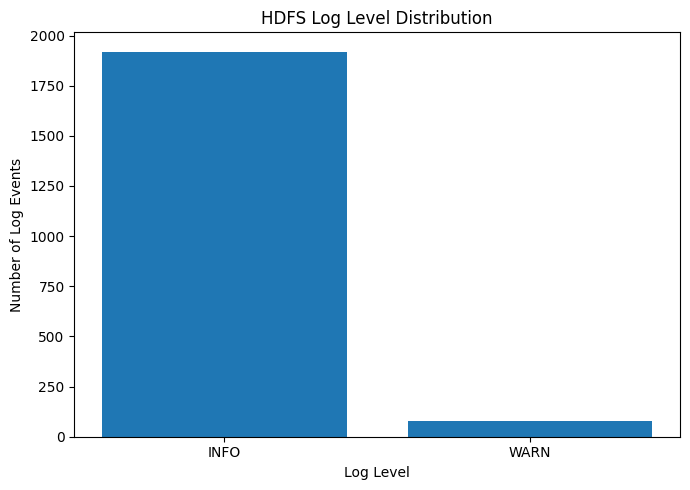

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/log_level_distribution.png


In [71]:
# ============================================================
# Step 3: Visualize log level distribution
# ============================================================

level_counts = logs_df["Level"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(level_counts.index, level_counts.values)
plt.title("HDFS Log Level Distribution")
plt.xlabel("Log Level")
plt.ylabel("Number of Log Events")
plt.tight_layout()

level_fig_path = FIGURE_DIR / "log_level_distribution.png"
plt.savefig(level_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", level_fig_path)

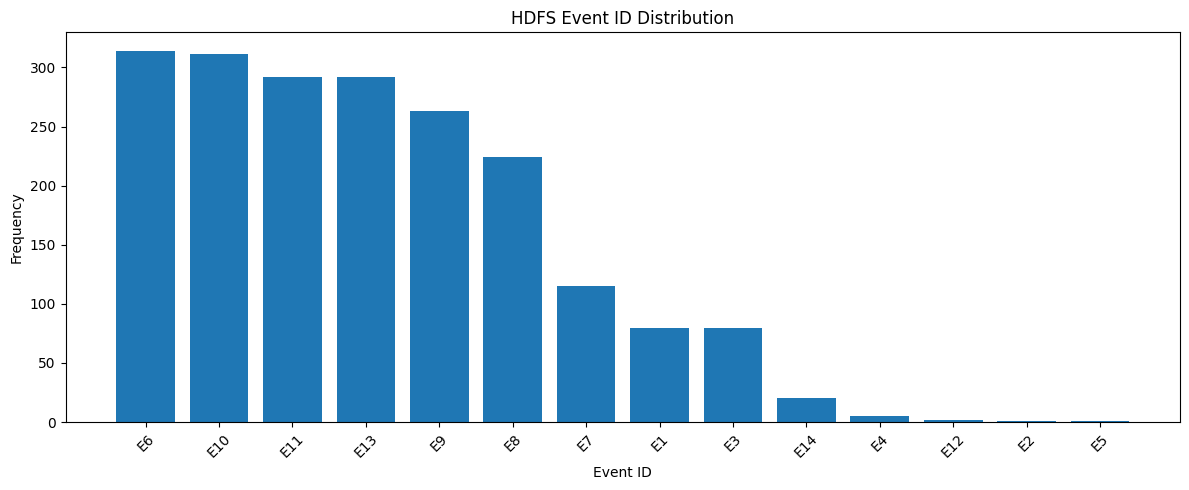

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/event_id_distribution.png


,EventId,frequency
0,E6,314
1,E10,311
2,E11,292
3,E13,292
4,E9,263
5,E8,224
6,E7,115
7,E1,80
8,E3,80
9,E14,20


In [72]:
# ============================================================
# Step 3: Visualize Event ID distribution
# ============================================================

event_counts = logs_df["EventId"].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(event_counts.index, event_counts.values)
plt.title("HDFS Event ID Distribution")
plt.xlabel("Event ID")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()

event_fig_path = FIGURE_DIR / "event_id_distribution.png"
plt.savefig(event_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", event_fig_path)

event_counts_df = event_counts.reset_index()
event_counts_df.columns = ["EventId", "frequency"]
display(event_counts_df)

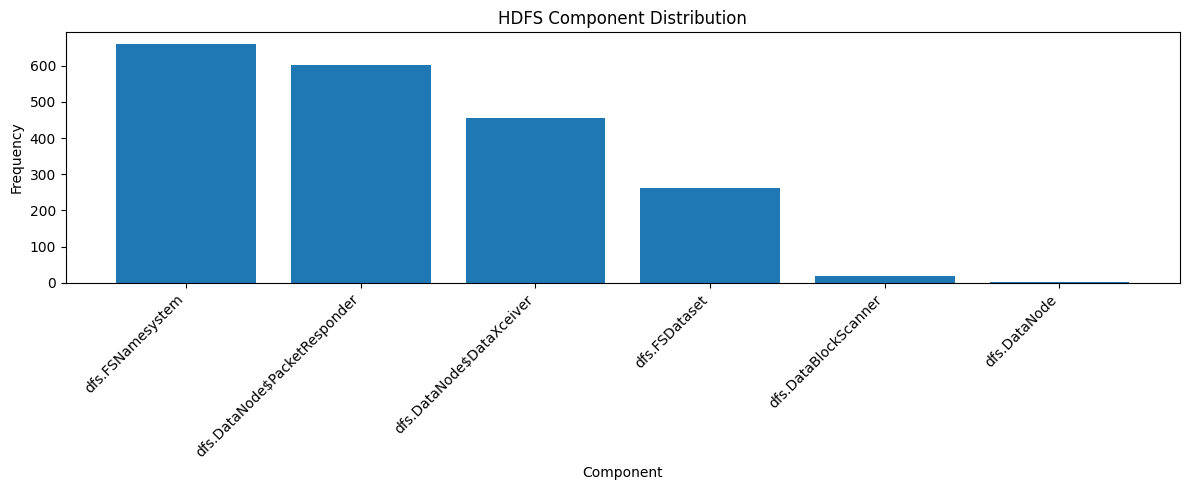

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/component_distribution.png


,Component,frequency
0,dfs.FSNamesystem,659
1,dfs.DataNode$PacketResponder,603
2,dfs.DataNode$DataXceiver,454
3,dfs.FSDataset,263
4,dfs.DataBlockScanner,20
5,dfs.DataNode,1


In [73]:
# ============================================================
# Step 3: Visualize component distribution
# ============================================================

component_counts = logs_df["Component"].value_counts()

plt.figure(figsize=(12, 5))
plt.bar(component_counts.index, component_counts.values)
plt.title("HDFS Component Distribution")
plt.xlabel("Component")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

component_fig_path = FIGURE_DIR / "component_distribution.png"
plt.savefig(component_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", component_fig_path)

component_counts_df = component_counts.reset_index()
component_counts_df.columns = ["Component", "frequency"]
display(component_counts_df)

In [74]:
# ============================================================
# Step 3: Event template frequency table
# ============================================================

template_frequency_df = logs_df.groupby(
    ["EventId", "EventTemplate"]
).size().reset_index(name="frequency")

template_frequency_df = template_frequency_df.sort_values(
    by="frequency",
    ascending=False
).reset_index(drop=True)

display(template_frequency_df)

template_frequency_df.to_csv(
    RESULTS_DIR / "event_template_frequency.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "event_template_frequency.csv")

,EventId,EventTemplate,frequency
0,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...,314
1,E10,PacketResponder <*> for block blk_<*> terminating,311
2,E13,Receiving block blk_<*> src: /<*>:<*> dest: /<...,292
3,E11,Received block blk_<*> of size <*> from /<*>,292
4,E9,Deleting block blk_<*> file /<*>/blk_<*>,263
5,E8,BLOCK* NameSystem.delete: blk_<*> is added to ...,224
6,E7,BLOCK* NameSystem.allocateBlock: /<*>/part-<*>...,115
7,E3,<*>:<*>:Got exception while serving blk_<*> to...,80
8,E1,<*>:<*> Served block blk_<*> to /<*>,80
9,E14,Verification succeeded for blk_<*>,20


Saved: secops_log_anomaly_triage_hdfs/results/event_template_frequency.csv


In [75]:
# ============================================================
# Step 3: WARN-level event analysis
# ============================================================

warn_logs_df = logs_df[logs_df["Level"] == "WARN"].copy()

print("Total WARN logs:", len(warn_logs_df))

print("\nWARN Event ID distribution:")
print(warn_logs_df["EventId"].value_counts())

print("\nWARN Component distribution:")
print(warn_logs_df["Component"].value_counts())

display(warn_logs_df.head(10))

Total WARN logs: 80

WARN Event ID distribution:
EventId
E3    80
Name: count, dtype: int64

WARN Component distribution:
Component
dfs.DataNode$DataXceiver    80
Name: count, dtype: int64


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate
77,78,81109,214043,2561,WARN,dfs.DataNode$DataXceiver,10.251.30.85:50010:Got exception while serving...,E3,<*>:<*>:Got exception while serving blk_<*> to...
78,79,81109,214402,2677,WARN,dfs.DataNode$DataXceiver,10.251.126.255:50010:Got exception while servi...,E3,<*>:<*>:Got exception while serving blk_<*> to...
80,81,81109,214529,2747,WARN,dfs.DataNode$DataXceiver,10.251.123.132:50010:Got exception while servi...,E3,<*>:<*>:Got exception while serving blk_<*> to...
81,82,81109,214910,2848,WARN,dfs.DataNode$DataXceiver,10.250.13.188:50010:Got exception while servin...,E3,<*>:<*>:Got exception while serving blk_<*> to...
83,84,81109,215136,2868,WARN,dfs.DataNode$DataXceiver,10.251.199.19:50010:Got exception while servin...,E3,<*>:<*>:Got exception while serving blk_<*> to...
84,85,81109,215259,2934,WARN,dfs.DataNode$DataXceiver,10.250.9.207:50010:Got exception while serving...,E3,<*>:<*>:Got exception while serving blk_<*> to...
85,86,81109,215702,3022,WARN,dfs.DataNode$DataXceiver,10.251.202.134:50010:Got exception while servi...,E3,<*>:<*>:Got exception while serving blk_<*> to...
87,88,81109,220032,3137,WARN,dfs.DataNode$DataXceiver,10.250.14.196:50010:Got exception while servin...,E3,<*>:<*>:Got exception while serving blk_<*> to...
88,89,81109,220403,3148,WARN,dfs.DataNode$DataXceiver,10.251.107.227:50010:Got exception while servi...,E3,<*>:<*>:Got exception while serving blk_<*> to...
90,91,81109,221105,3338,WARN,dfs.DataNode$DataXceiver,10.251.90.64:50010:Got exception while serving...,E3,<*>:<*>:Got exception while serving blk_<*> to...


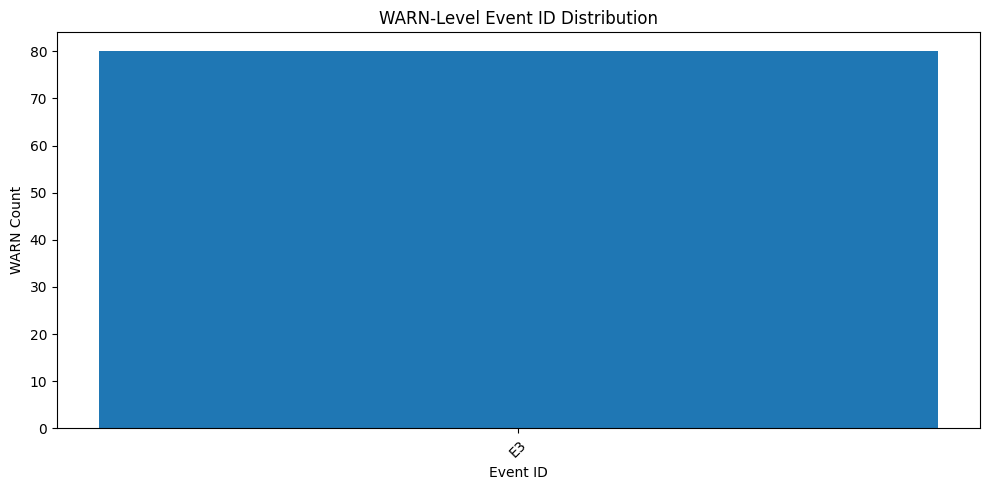

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/warn_event_id_distribution.png


In [76]:
# ============================================================
# Step 3: Visualize WARN Event ID distribution
# ============================================================

warn_event_counts = warn_logs_df["EventId"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(warn_event_counts.index, warn_event_counts.values)
plt.title("WARN-Level Event ID Distribution")
plt.xlabel("Event ID")
plt.ylabel("WARN Count")
plt.xticks(rotation=45)
plt.tight_layout()

warn_event_fig_path = FIGURE_DIR / "warn_event_id_distribution.png"
plt.savefig(warn_event_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", warn_event_fig_path)

In [77]:
# ============================================================
# Step 3: Component vs Event ID frequency matrix
# ============================================================

component_event_matrix = pd.crosstab(
    logs_df["Component"],
    logs_df["EventId"]
)

display(component_event_matrix)

component_event_matrix.to_csv(
    RESULTS_DIR / "component_event_matrix.csv"
)

print("Saved:", RESULTS_DIR / "component_event_matrix.csv")

EventId,E1,E10,E11,E12,E13,E14,E2,E3,E4,E5,E6,E7,E8,E9
Component,,,,,,,,,,,,,,
dfs.DataBlockScanner,0,0,0,0,0,20,0,0,0,0,0,0,0,0
dfs.DataNode,0,0,0,0,0,0,1,0,0,0,0,0,0,0
dfs.DataNode$DataXceiver,80,0,0,2,292,0,0,80,0,0,0,0,0,0
dfs.DataNode$PacketResponder,0,311,292,0,0,0,0,0,0,0,0,0,0,0
dfs.FSDataset,0,0,0,0,0,0,0,0,0,0,0,0,0,263
dfs.FSNamesystem,0,0,0,0,0,0,0,0,5,1,314,115,224,0


Saved: secops_log_anomaly_triage_hdfs/results/component_event_matrix.csv


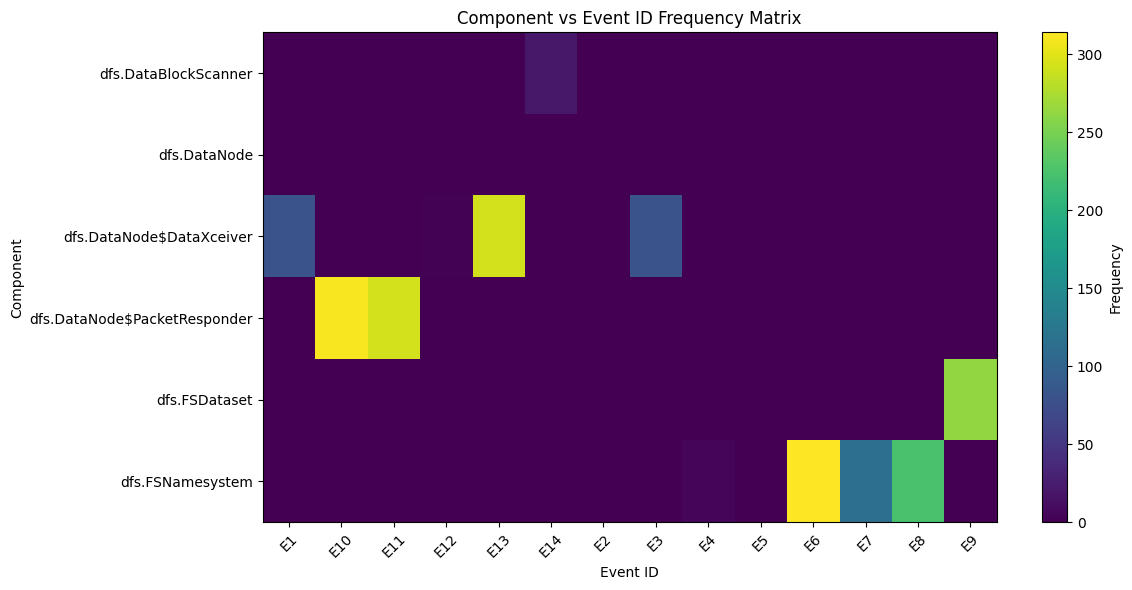

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/component_event_heatmap.png


In [78]:
# ============================================================
# Step 3: Visualize Component vs Event ID matrix
# ============================================================

plt.figure(figsize=(12, 6))
plt.imshow(component_event_matrix.values, aspect="auto")
plt.colorbar(label="Frequency")

plt.xticks(
    ticks=np.arange(len(component_event_matrix.columns)),
    labels=component_event_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(component_event_matrix.index)),
    labels=component_event_matrix.index
)

plt.title("Component vs Event ID Frequency Matrix")
plt.xlabel("Event ID")
plt.ylabel("Component")
plt.tight_layout()

component_event_heatmap_path = FIGURE_DIR / "component_event_heatmap.png"
plt.savefig(component_event_heatmap_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", component_event_heatmap_path)

In [79]:
# ============================================================
# Step 3: Save EDA summary
# ============================================================

eda_summary = {
    "total_log_events": int(len(logs_df)),
    "total_templates": int(len(templates_df)),
    "unique_event_ids": int(logs_df["EventId"].nunique()),
    "unique_components": int(logs_df["Component"].nunique()),
    "info_logs": int((logs_df["Level"] == "INFO").sum()),
    "warn_logs": int((logs_df["Level"] == "WARN").sum()),
    "most_common_event_id": str(logs_df["EventId"].value_counts().idxmax()),
    "most_common_component": str(logs_df["Component"].value_counts().idxmax()),
}

eda_summary_path = RESULTS_DIR / "eda_summary.json"

with open(eda_summary_path, "w") as f:
    json.dump(eda_summary, f, indent=4)

print("EDA Summary:")
print(json.dumps(eda_summary, indent=4))

print("\nSaved:", eda_summary_path)

EDA Summary:
{
    "total_log_events": 2000,
    "total_templates": 14,
    "unique_event_ids": 14,
    "unique_components": 6,
    "info_logs": 1920,
    "warn_logs": 80,
    "most_common_event_id": "E6",
    "most_common_component": "dfs.FSNamesystem"
}

Saved: secops_log_anomaly_triage_hdfs/results/eda_summary.json


In [80]:
# ============================================================
# Step 4: Extract HDFS block IDs from log content
# ============================================================

def extract_block_ids(text):
    """
    Extract all HDFS block IDs from a log content string.
    Example block IDs:
    - blk_38865049064139660
    - blk_-6952295868487656571
    """
    return re.findall(r"blk_-?\d+", str(text))


logs_df["block_ids"] = logs_df["Content"].apply(extract_block_ids)
logs_df["block_id_count"] = logs_df["block_ids"].apply(len)

# Use the first block ID as the primary session ID.
# Most HDFS log lines in this dataset contain one block ID.
logs_df["block_id"] = logs_df["block_ids"].apply(
    lambda ids: ids[0] if len(ids) > 0 else np.nan
)

print("Total log lines:", len(logs_df))
print("Logs with block ID:", logs_df["block_id"].notna().sum())
print("Logs without block ID:", logs_df["block_id"].isna().sum())
print("Unique block/session IDs:", logs_df["block_id"].nunique())

display(logs_df[["LineId", "Level", "Component", "EventId", "block_id", "Content"]].head(10))

Total log lines: 2000
Logs with block ID: 2000
Logs without block ID: 0
Unique block/session IDs: 1994


,LineId,Level,Component,EventId,block_id,Content
0,1,INFO,dfs.DataNode$PacketResponder,E10,blk_38865049064139660,PacketResponder 1 for block blk_38865049064139...
1,2,INFO,dfs.DataNode$PacketResponder,E10,blk_-6952295868487656571,PacketResponder 0 for block blk_-6952295868487...
2,3,INFO,dfs.FSNamesystem,E6,blk_7128370237687728475,BLOCK* NameSystem.addStoredBlock: blockMap upd...
3,4,INFO,dfs.DataNode$PacketResponder,E10,blk_8229193803249955061,PacketResponder 2 for block blk_82291938032499...
4,5,INFO,dfs.DataNode$PacketResponder,E10,blk_-6670958622368987959,PacketResponder 2 for block blk_-6670958622368...
5,6,INFO,dfs.FSNamesystem,E6,blk_3050920587428079149,BLOCK* NameSystem.addStoredBlock: blockMap upd...
6,7,INFO,dfs.FSNamesystem,E6,blk_7888946331804732825,BLOCK* NameSystem.addStoredBlock: blockMap upd...
7,8,INFO,dfs.FSNamesystem,E6,blk_2377150260128098806,BLOCK* NameSystem.addStoredBlock: blockMap upd...
8,9,INFO,dfs.DataNode$PacketResponder,E10,blk_572492839287299681,PacketResponder 2 for block blk_57249283928729...
9,10,INFO,dfs.DataNode$PacketResponder,E11,blk_3587508140051953248,Received block blk_3587508140051953248 of size...


In [81]:
# ============================================================
# Step 4: Check logs containing multiple block IDs
# ============================================================

multi_block_logs = logs_df[logs_df["block_id_count"] > 1].copy()

print("Logs with multiple block IDs:", len(multi_block_logs))

if len(multi_block_logs) > 0:
    display(multi_block_logs[["LineId", "EventId", "block_ids", "Content"]].head(10))
else:
    print("No multi-block log lines found.")

Logs with multiple block IDs: 266


,LineId,EventId,block_ids,Content
72,73,E9,"[blk_1781953582842324563, blk_1781953582842324...",Deleting block blk_1781953582842324563 file /m...
425,426,E9,"[blk_8483848473254499625, blk_8483848473254499...",Deleting block blk_8483848473254499625 file /m...
427,428,E9,"[blk_-8898274302731129139, blk_-88982743027311...",Deleting block blk_-8898274302731129139 file /...
428,429,E9,"[blk_-8014701913801168461, blk_-80147019138011...",Deleting block blk_-8014701913801168461 file /...
429,430,E9,"[blk_-8775602795571523802, blk_-87756027955715...",Deleting block blk_-8775602795571523802 file /...
430,431,E9,"[blk_-7928230000822317050, blk_-79282300008223...",Deleting block blk_-7928230000822317050 file /...
431,432,E9,"[blk_8303413189200230139, blk_8303413189200230...",Deleting block blk_8303413189200230139 file /m...
432,433,E9,"[blk_-9038475355621289969, blk_-90384753556212...",Deleting block blk_-9038475355621289969 file /...
434,435,E9,"[blk_-8848810702648406400, blk_-88488107026484...",Deleting block blk_-8848810702648406400 file /...
437,438,E9,"[blk_-7515058933811567980, blk_-75150589338115...",Deleting block blk_-7515058933811567980 file /...


In [82]:
# ============================================================
# Step 4: Keep logs that contain block/session IDs
# ============================================================

block_logs_df = logs_df.dropna(subset=["block_id"]).copy()

block_logs_df = block_logs_df.sort_values(
    by=["block_id", "LineId"]
).reset_index(drop=True)

print("Block-level log shape:", block_logs_df.shape)
print("Unique block sessions:", block_logs_df["block_id"].nunique())

display(block_logs_df.head())

Block-level log shape: (2000, 12)
Unique block sessions: 1994


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate,block_ids,block_id_count,block_id
0,1853,81111,85914,27,INFO,dfs.FSNamesystem,BLOCK* NameSystem.delete: blk_-103083204619798...,E8,BLOCK* NameSystem.delete: blk_<*> is added to ...,[blk_-1030832046197982436],1,blk_-1030832046197982436
1,1401,81111,44700,19,INFO,dfs.FSDataset,Deleting block blk_-1046472716157313227 file /...,E9,Deleting block blk_<*> file /<*>/blk_<*>,"[blk_-1046472716157313227, blk_-10464727161573...",2,blk_-1046472716157313227
2,1700,81111,75054,23885,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1049340855430...,E10,PacketResponder <*> for block blk_<*> terminating,[blk_-1049340855430710153],1,blk_-1049340855430710153
3,161,81110,727,34,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap upd...,E6,BLOCK* NameSystem.addStoredBlock: blockMap upd...,[blk_-1055254430948037872],1,blk_-1055254430948037872
4,1488,81111,54342,20995,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1067234447809...,E10,PacketResponder <*> for block blk_<*> terminating,[blk_-1067234447809438340],1,blk_-1067234447809438340


In [83]:
# ============================================================
# Step 4: Build session/block trace table
# ============================================================

def join_sequence(values):
    """
    Convert a sequence into a readable trace string.
    """
    return " -> ".join([str(v) for v in values])


session_trace_rows = []

for block_id, group in block_logs_df.groupby("block_id"):
    group = group.sort_values("LineId")

    event_sequence = group["EventId"].tolist()
    component_sequence = group["Component"].tolist()
    level_sequence = group["Level"].tolist()

    session_trace_rows.append({
        "block_id": block_id,
        "log_count": len(group),
        "first_line_id": group["LineId"].min(),
        "last_line_id": group["LineId"].max(),
        "line_span": group["LineId"].max() - group["LineId"].min(),
        "first_event": event_sequence[0],
        "last_event": event_sequence[-1],
        "unique_event_count": group["EventId"].nunique(),
        "unique_component_count": group["Component"].nunique(),
        "warn_count": (group["Level"] == "WARN").sum(),
        "info_count": (group["Level"] == "INFO").sum(),
        "has_warn": int((group["Level"] == "WARN").any()),
        "event_sequence": join_sequence(event_sequence),
        "component_sequence": join_sequence(component_sequence),
        "level_sequence": join_sequence(level_sequence)
    })

session_traces_df = pd.DataFrame(session_trace_rows)

print("Session traces shape:", session_traces_df.shape)

display(session_traces_df.head())

Session traces shape: (1994, 15)


,block_id,log_count,first_line_id,last_line_id,line_span,first_event,last_event,unique_event_count,unique_component_count,warn_count,info_count,has_warn,event_sequence,component_sequence,level_sequence
0,blk_-1030832046197982436,1,1853,1853,0,E8,E8,1,1,0,1,0,E8,dfs.FSNamesystem,INFO
1,blk_-1046472716157313227,1,1401,1401,0,E9,E9,1,1,0,1,0,E9,dfs.FSDataset,INFO
2,blk_-1049340855430710153,1,1700,1700,0,E10,E10,1,1,0,1,0,E10,dfs.DataNode$PacketResponder,INFO
3,blk_-1055254430948037872,1,161,161,0,E6,E6,1,1,0,1,0,E6,dfs.FSNamesystem,INFO
4,blk_-1067234447809438340,1,1488,1488,0,E10,E10,1,1,0,1,0,E10,dfs.DataNode$PacketResponder,INFO


In [84]:
# ============================================================
# Step 4: Session trace summary
# ============================================================

session_summary = {
    "total_sessions": int(len(session_traces_df)),
    "average_logs_per_session": float(round(session_traces_df["log_count"].mean(), 2)),
    "median_logs_per_session": float(session_traces_df["log_count"].median()),
    "max_logs_per_session": int(session_traces_df["log_count"].max()),
    "sessions_with_warn": int(session_traces_df["has_warn"].sum()),
    "average_unique_events_per_session": float(round(session_traces_df["unique_event_count"].mean(), 2)),
    "max_unique_events_per_session": int(session_traces_df["unique_event_count"].max())
}

print("Session Trace Summary:")
print(json.dumps(session_summary, indent=4))

Session Trace Summary:
{
    "total_sessions": 1994,
    "average_logs_per_session": 1.0,
    "median_logs_per_session": 1.0,
    "max_logs_per_session": 2,
    "sessions_with_warn": 80,
    "average_unique_events_per_session": 1.0,
    "max_unique_events_per_session": 2
}


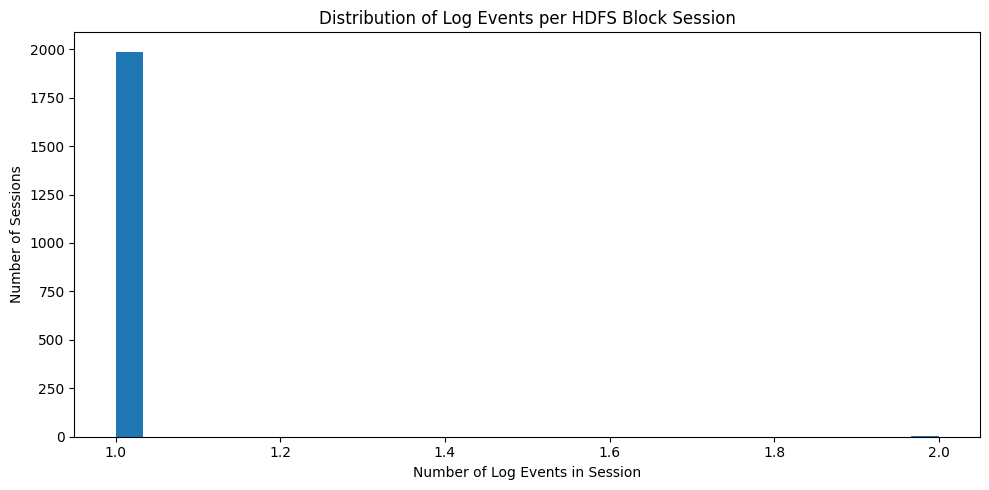

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/session_log_count_distribution.png


In [85]:
# ============================================================
# Step 4: Visualize logs per session
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(session_traces_df["log_count"], bins=30)
plt.title("Distribution of Log Events per HDFS Block Session")
plt.xlabel("Number of Log Events in Session")
plt.ylabel("Number of Sessions")
plt.tight_layout()

session_log_count_fig_path = FIGURE_DIR / "session_log_count_distribution.png"
plt.savefig(session_log_count_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", session_log_count_fig_path)

In [86]:
# ============================================================
# Step 4: Top sessions by log count
# ============================================================

top_log_count_sessions = session_traces_df.sort_values(
    by="log_count",
    ascending=False
).head(10)

display(top_log_count_sessions[
    [
        "block_id",
        "log_count",
        "unique_event_count",
        "unique_component_count",
        "warn_count",
        "event_sequence"
    ]
])

,block_id,log_count,unique_event_count,unique_component_count,warn_count,event_sequence
694,blk_-7029628814943626474,2,2,2,1,E11 -> E3
1729,blk_707166530951154301,2,2,2,0,E10 -> E6
924,blk_-8775602795571523802,2,1,1,0,E9 -> E9
380,blk_-4411589101766563890,2,2,2,0,E10 -> E12
1912,blk_8596624696139957935,2,2,2,0,E13 -> E7
1647,blk_6400082566804273401,2,2,2,0,E7 -> E13
1335,blk_3894335463008345041,1,1,1,0,E14
1334,blk_38865049064139660,1,1,1,0,E10
1333,blk_3876184938151091897,1,1,1,0,E8
1332,blk_387577766066135394,1,1,1,0,E7


In [87]:
# ============================================================
# Step 4: Sessions containing WARN logs
# ============================================================

warn_sessions = session_traces_df[session_traces_df["has_warn"] == 1].copy()

print("Sessions containing WARN logs:", len(warn_sessions))

display(warn_sessions[
    [
        "block_id",
        "log_count",
        "unique_event_count",
        "unique_component_count",
        "warn_count",
        "event_sequence"
    ]
].head(15))

Sessions containing WARN logs: 80


,block_id,log_count,unique_event_count,unique_component_count,warn_count,event_sequence
44,blk_-1367876730256254709,1,1,1,1,E3
61,blk_-1508527605812345693,1,1,1,1,E3
108,blk_-1851265222873801714,1,1,1,1,E3
132,blk_-20269367189114433,1,1,1,1,E3
133,blk_-2032740670708110312,1,1,1,1,E3
195,blk_-272707591443354058,1,1,1,1,E3
215,blk_-2918118818249673980,1,1,1,1,E3
229,blk_-305633040016166849,1,1,1,1,E3
230,blk_-3056652732896088330,1,1,1,1,E3
234,blk_-3140031507252212554,1,1,1,1,E3


In [88]:
# ============================================================
# Step 4: Save session trace outputs
# ============================================================

session_traces_path = DATA_DIR / "hdfs_block_session_traces.csv"
block_logs_path = DATA_DIR / "hdfs_block_level_logs.csv"
session_summary_path = RESULTS_DIR / "session_trace_summary.json"

session_traces_df.to_csv(session_traces_path, index=False)
block_logs_df.to_csv(block_logs_path, index=False)

with open(session_summary_path, "w") as f:
    json.dump(session_summary, f, indent=4)

print("Saved session traces:", session_traces_path)
print("Saved block-level logs:", block_logs_path)
print("Saved session summary:", session_summary_path)

Saved session traces: secops_log_anomaly_triage_hdfs/data/hdfs_block_session_traces.csv
Saved block-level logs: secops_log_anomaly_triage_hdfs/data/hdfs_block_level_logs.csv
Saved session summary: secops_log_anomaly_triage_hdfs/results/session_trace_summary.json


In [89]:
# ============================================================
# Step 5: Keyword-based feature extraction
# ============================================================

def count_keyword_occurrences(series, keyword_pattern):
    """
    Count how many log messages in a session contain a keyword pattern.
    """
    return series.astype(str).str.lower().str.contains(
        keyword_pattern,
        regex=True
    ).sum()


keyword_feature_rows = []

for block_id, group in block_logs_df.groupby("block_id"):
    content_series = group["Content"]

    keyword_feature_rows.append({
        "block_id": block_id,
        "exception_keyword_count": count_keyword_occurrences(
            content_series,
            r"exception|error|failed|fail|fault"
        ),
        "delete_keyword_count": count_keyword_occurrences(
            content_series,
            r"delete|deleted|remove|removed"
        ),
        "transfer_keyword_count": count_keyword_occurrences(
            content_series,
            r"transfer|transmit|send|served"
        ),
        "blockmap_keyword_count": count_keyword_occurrences(
            content_series,
            r"blockmap|addstoredblock|namesystem"
        ),
        "replicate_keyword_count": count_keyword_occurrences(
            content_series,
            r"replicate|replication"
        )
    })

keyword_features_df = pd.DataFrame(keyword_feature_rows)

print("Keyword feature shape:", keyword_features_df.shape)
display(keyword_features_df.head())

Keyword feature shape: (1994, 6)


,block_id,exception_keyword_count,delete_keyword_count,transfer_keyword_count,blockmap_keyword_count,replicate_keyword_count
0,blk_-1030832046197982436,0,1,0,1,0
1,blk_-1046472716157313227,0,0,0,0,0
2,blk_-1049340855430710153,0,0,0,0,0
3,blk_-1055254430948037872,0,0,0,1,0
4,blk_-1067234447809438340,0,0,0,0,0


In [90]:
# ============================================================
# Step 5: Event ID frequency features
# ============================================================

event_frequency_features = pd.crosstab(
    block_logs_df["block_id"],
    block_logs_df["EventId"]
).reset_index()

# Rename event columns for clarity
event_frequency_features = event_frequency_features.rename(
    columns={
        col: f"event_count_{col}"
        for col in event_frequency_features.columns
        if col != "block_id"
    }
)

print("Event frequency feature shape:", event_frequency_features.shape)
display(event_frequency_features.head())

Event frequency feature shape: (1994, 15)


EventId,block_id,event_count_E1,event_count_E10,event_count_E11,event_count_E12,event_count_E13,event_count_E14,event_count_E2,event_count_E3,event_count_E4,event_count_E5,event_count_E6,event_count_E7,event_count_E8,event_count_E9
0,blk_-1030832046197982436,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,blk_-1046472716157313227,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,blk_-1049340855430710153,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,blk_-1055254430948037872,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,blk_-1067234447809438340,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [91]:
# ============================================================
# Step 5: Component frequency features
# ============================================================

component_frequency_features = pd.crosstab(
    block_logs_df["block_id"],
    block_logs_df["Component"]
).reset_index()

# Rename component columns safely
component_frequency_features = component_frequency_features.rename(
    columns={
        col: "component_count_" + str(col).replace(".", "_").replace("$", "_")
        for col in component_frequency_features.columns
        if col != "block_id"
    }
)

print("Component frequency feature shape:", component_frequency_features.shape)
display(component_frequency_features.head())

Component frequency feature shape: (1994, 7)


Component,block_id,component_count_dfs_DataBlockScanner,component_count_dfs_DataNode,component_count_dfs_DataNode_DataXceiver,component_count_dfs_DataNode_PacketResponder,component_count_dfs_FSDataset,component_count_dfs_FSNamesystem
0,blk_-1030832046197982436,0,0,0,0,0,1
1,blk_-1046472716157313227,0,0,0,0,1,0
2,blk_-1049340855430710153,0,0,0,1,0,0
3,blk_-1055254430948037872,0,0,0,0,0,1
4,blk_-1067234447809438340,0,0,0,1,0,0


In [92]:
# ============================================================
# Step 5: Log level frequency features
# ============================================================

level_frequency_features = pd.crosstab(
    block_logs_df["block_id"],
    block_logs_df["Level"]
).reset_index()

level_frequency_features = level_frequency_features.rename(
    columns={
        col: f"level_count_{col}"
        for col in level_frequency_features.columns
        if col != "block_id"
    }
)

print("Level frequency feature shape:", level_frequency_features.shape)
display(level_frequency_features.head())

Level frequency feature shape: (1994, 3)


Level,block_id,level_count_INFO,level_count_WARN
0,blk_-1030832046197982436,1,0
1,blk_-1046472716157313227,1,0
2,blk_-1049340855430710153,1,0
3,blk_-1055254430948037872,1,0
4,blk_-1067234447809438340,1,0


In [93]:
# ============================================================
# Step 5: Merge all session-level features
# ============================================================

session_features_df = session_traces_df.copy()

session_features_df = session_features_df.merge(
    keyword_features_df,
    on="block_id",
    how="left"
)

session_features_df = session_features_df.merge(
    event_frequency_features,
    on="block_id",
    how="left"
)

session_features_df = session_features_df.merge(
    component_frequency_features,
    on="block_id",
    how="left"
)

session_features_df = session_features_df.merge(
    level_frequency_features,
    on="block_id",
    how="left"
)

session_features_df = session_features_df.fillna(0)

print("Final session feature table shape:", session_features_df.shape)

display(session_features_df.head())

Final session feature table shape: (1994, 42)


,block_id,log_count,first_line_id,last_line_id,line_span,first_event,last_event,unique_event_count,unique_component_count,warn_count,...,event_count_E8,event_count_E9,component_count_dfs_DataBlockScanner,component_count_dfs_DataNode,component_count_dfs_DataNode_DataXceiver,component_count_dfs_DataNode_PacketResponder,component_count_dfs_FSDataset,component_count_dfs_FSNamesystem,level_count_INFO,level_count_WARN
0,blk_-1030832046197982436,1,1853,1853,0,E8,E8,1,1,0,...,1,0,0,0,0,0,0,1,1,0
1,blk_-1046472716157313227,1,1401,1401,0,E9,E9,1,1,0,...,0,1,0,0,0,0,1,0,1,0
2,blk_-1049340855430710153,1,1700,1700,0,E10,E10,1,1,0,...,0,0,0,0,0,1,0,0,1,0
3,blk_-1055254430948037872,1,161,161,0,E6,E6,1,1,0,...,0,0,0,0,0,0,0,1,1,0
4,blk_-1067234447809438340,1,1488,1488,0,E10,E10,1,1,0,...,0,0,0,0,0,1,0,0,1,0


In [94]:
# ============================================================
# Step 5: Separate metadata and numeric feature columns
# ============================================================

metadata_columns = [
    "block_id",
    "first_event",
    "last_event",
    "event_sequence",
    "component_sequence",
    "level_sequence"
]

numeric_feature_columns = [
    col for col in session_features_df.columns
    if col not in metadata_columns
]

# Keep only numeric columns
numeric_feature_columns = [
    col for col in numeric_feature_columns
    if pd.api.types.is_numeric_dtype(session_features_df[col])
]

X_features = session_features_df[numeric_feature_columns].copy()

print("Number of numeric features:", len(numeric_feature_columns))
print("Numeric feature matrix shape:", X_features.shape)

display(X_features.head())

Number of numeric features: 36
Numeric feature matrix shape: (1994, 36)


,log_count,first_line_id,last_line_id,line_span,unique_event_count,unique_component_count,warn_count,info_count,has_warn,exception_keyword_count,...,event_count_E8,event_count_E9,component_count_dfs_DataBlockScanner,component_count_dfs_DataNode,component_count_dfs_DataNode_DataXceiver,component_count_dfs_DataNode_PacketResponder,component_count_dfs_FSDataset,component_count_dfs_FSNamesystem,level_count_INFO,level_count_WARN
0,1,1853,1853,0,1,1,0,1,0,0,...,1,0,0,0,0,0,0,1,1,0
1,1,1401,1401,0,1,1,0,1,0,0,...,0,1,0,0,0,0,1,0,1,0
2,1,1700,1700,0,1,1,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0
3,1,161,161,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0
4,1,1488,1488,0,1,1,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0


In [95]:
# ============================================================
# Step 5: Feature summary for documentation
# ============================================================

feature_summary_df = pd.DataFrame({
    "feature_name": numeric_feature_columns,
    "non_zero_count": [int((X_features[col] != 0).sum()) for col in numeric_feature_columns],
    "mean_value": [round(float(X_features[col].mean()), 4) for col in numeric_feature_columns],
    "max_value": [float(X_features[col].max()) for col in numeric_feature_columns]
})

display(feature_summary_df)

feature_summary_df.to_csv(
    RESULTS_DIR / "session_feature_summary.csv",
    index=False
)

print("Saved feature summary:", RESULTS_DIR / "session_feature_summary.csv")

,feature_name,non_zero_count,mean_value,max_value
0,log_count,1994,1.0030,2.0
1,first_line_id,1994,999.6319,2000.0
2,last_line_id,1994,999.9082,2000.0
3,line_span,6,0.2763,527.0
4,unique_event_count,1994,1.0025,2.0
5,unique_component_count,1994,1.0025,2.0
6,warn_count,80,0.0401,1.0
7,info_count,1915,0.9629,2.0
8,has_warn,80,0.0401,1.0
9,exception_keyword_count,80,0.0401,1.0


Saved feature summary: secops_log_anomaly_triage_hdfs/results/session_feature_summary.csv


In [96]:
# ============================================================
# Step 5: Save session-level feature table
# ============================================================

session_features_path = DATA_DIR / "hdfs_session_level_features.csv"
numeric_features_path = DATA_DIR / "hdfs_numeric_feature_matrix.csv"

session_features_df.to_csv(session_features_path, index=False)
X_features.to_csv(numeric_features_path, index=False)

print("Saved session-level features:", session_features_path)
print("Saved numeric feature matrix:", numeric_features_path)

Saved session-level features: secops_log_anomaly_triage_hdfs/data/hdfs_session_level_features.csv
Saved numeric feature matrix: secops_log_anomaly_triage_hdfs/data/hdfs_numeric_feature_matrix.csv


In [97]:
# ============================================================
# Step 5: Quick interpretation of important risk features
# ============================================================

important_feature_columns = [
    "log_count",
    "warn_count",
    "has_warn",
    "exception_keyword_count",
    "delete_keyword_count",
    "transfer_keyword_count",
    "unique_event_count",
    "unique_component_count"
]

existing_important_features = [
    col for col in important_feature_columns
    if col in session_features_df.columns
]

important_feature_summary = session_features_df[existing_important_features].describe().T

display(important_feature_summary)

,count,mean,std,min,25%,50%,75%,max
log_count,1994.0,1.003009,0.054786,1.0,1.0,1.0,1.0,2.0
warn_count,1994.0,0.040120,0.196291,0.0,0.0,0.0,0.0,1.0
has_warn,1994.0,0.040120,0.196291,0.0,0.0,0.0,0.0,1.0
exception_keyword_count,1994.0,0.040120,0.196291,0.0,0.0,0.0,0.0,1.0
delete_keyword_count,1994.0,0.114845,0.318914,0.0,0.0,0.0,0.0,1.0
transfer_keyword_count,1994.0,0.040622,0.197462,0.0,0.0,0.0,0.0,1.0
unique_event_count,1994.0,1.002508,0.050025,1.0,1.0,1.0,1.0,2.0
unique_component_count,1994.0,1.002508,0.050025,1.0,1.0,1.0,1.0,2.0


In [98]:
# ============================================================
# Step 6: Define rule-based SecOps risk configuration
# ============================================================

RISK_RULE_WEIGHTS = {
    "warn_log_present": 4,
    "exception_keyword_present": 4,
    "event_e3_present": 4,
    "delete_activity_present": 2,
    "transfer_activity_present": 1,
    "multi_event_session": 1,
    "multi_component_session": 1,
    "high_log_count_session": 1
}

print("Rule-based risk configuration:")
for rule, weight in RISK_RULE_WEIGHTS.items():
    print(f"{rule}: +{weight}")

Rule-based risk configuration:
warn_log_present: +4
exception_keyword_present: +4
event_e3_present: +4
delete_activity_present: +2
transfer_activity_present: +1
multi_event_session: +1
multi_component_session: +1
high_log_count_session: +1


In [99]:
# ============================================================
# Step 6: Create rule-based risk score
# ============================================================

risk_df = session_features_df.copy()

# Start risk score from zero
risk_df["rule_risk_score"] = 0

# Store explanation reasons
risk_reasons = []

for _, row in risk_df.iterrows():
    score = 0
    reasons = []

    # Rule 1: WARN log present
    if row.get("warn_count", 0) > 0 or row.get("has_warn", 0) > 0:
        score += RISK_RULE_WEIGHTS["warn_log_present"]
        reasons.append("contains WARN-level log")

    # Rule 2: Exception/error keyword present
    if row.get("exception_keyword_count", 0) > 0:
        score += RISK_RULE_WEIGHTS["exception_keyword_present"]
        reasons.append("contains exception/error/failure keyword")

    # Rule 3: Event E3 present
    # E3 was found during EDA as the WARN exception event.
    if row.get("event_count_E3", 0) > 0:
        score += RISK_RULE_WEIGHTS["event_e3_present"]
        reasons.append("contains Event ID E3 linked to exception while serving block")

    # Rule 4: Delete/remove activity
    if row.get("delete_keyword_count", 0) > 0:
        score += RISK_RULE_WEIGHTS["delete_activity_present"]
        reasons.append("contains delete/remove-related activity")

    # Rule 5: Transfer/send/served activity
    if row.get("transfer_keyword_count", 0) > 0:
        score += RISK_RULE_WEIGHTS["transfer_activity_present"]
        reasons.append("contains transfer/send/served activity")

    # Rule 6: Multiple unique events
    if row.get("unique_event_count", 0) > 1:
        score += RISK_RULE_WEIGHTS["multi_event_session"]
        reasons.append("contains multiple unique Event IDs")

    # Rule 7: Multiple components
    if row.get("unique_component_count", 0) > 1:
        score += RISK_RULE_WEIGHTS["multi_component_session"]
        reasons.append("involves multiple HDFS components")

    # Rule 8: More logs than usual
    if row.get("log_count", 0) > risk_df["log_count"].median():
        score += RISK_RULE_WEIGHTS["high_log_count_session"]
        reasons.append("has higher-than-typical log count for this sample")

    risk_reasons.append("; ".join(reasons) if reasons else "No rule-based risk indicator detected.")
    risk_df.loc[row.name, "rule_risk_score"] = score

risk_df["rule_risk_reason"] = risk_reasons

display(risk_df[
    [
        "block_id",
        "rule_risk_score",
        "rule_risk_reason",
        "event_sequence",
        "level_sequence",
        "component_sequence"
    ]
].sort_values("rule_risk_score", ascending=False).head(15))

,block_id,rule_risk_score,rule_risk_reason,event_sequence,level_sequence,component_sequence
694,blk_-7029628814943626474,15,contains WARN-level log; contains exception/er...,E11 -> E3,INFO -> WARN,dfs.DataNode$PacketResponder -> dfs.DataNode$D...
1897,blk_8478683141242372735,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
349,blk_-4181768899028058192,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
1894,blk_8466246428293623262,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
61,blk_-1508527605812345693,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
1780,blk_7517964792804498202,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
487,blk_-5340885607150360719,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
1813,blk_7760079751081658559,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
672,blk_-6900989714336081087,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver
649,blk_-667933171485085225,12,contains WARN-level log; contains exception/er...,E3,WARN,dfs.DataNode$DataXceiver


In [100]:
# ============================================================
# Step 6: Convert rule risk score into severity level
# ============================================================

def assign_rule_risk_level(score):
    if score >= 10:
        return "Critical"
    elif score >= 6:
        return "High"
    elif score >= 3:
        return "Medium"
    else:
        return "Low"


risk_df["rule_risk_level"] = risk_df["rule_risk_score"].apply(assign_rule_risk_level)

print("Rule-based risk level distribution:")
print(risk_df["rule_risk_level"].value_counts())

display(risk_df[
    [
        "block_id",
        "rule_risk_level",
        "rule_risk_score",
        "rule_risk_reason",
        "event_sequence"
    ]
].sort_values("rule_risk_score", ascending=False).head(20))

Rule-based risk level distribution:
rule_risk_level
Low         1910
Critical      80
Medium         4
Name: count, dtype: int64


,block_id,rule_risk_level,rule_risk_score,rule_risk_reason,event_sequence
694,blk_-7029628814943626474,Critical,15,contains WARN-level log; contains exception/er...,E11 -> E3
1897,blk_8478683141242372735,Critical,12,contains WARN-level log; contains exception/er...,E3
349,blk_-4181768899028058192,Critical,12,contains WARN-level log; contains exception/er...,E3
1894,blk_8466246428293623262,Critical,12,contains WARN-level log; contains exception/er...,E3
61,blk_-1508527605812345693,Critical,12,contains WARN-level log; contains exception/er...,E3
1780,blk_7517964792804498202,Critical,12,contains WARN-level log; contains exception/er...,E3
487,blk_-5340885607150360719,Critical,12,contains WARN-level log; contains exception/er...,E3
1813,blk_7760079751081658559,Critical,12,contains WARN-level log; contains exception/er...,E3
672,blk_-6900989714336081087,Critical,12,contains WARN-level log; contains exception/er...,E3
649,blk_-667933171485085225,Critical,12,contains WARN-level log; contains exception/er...,E3


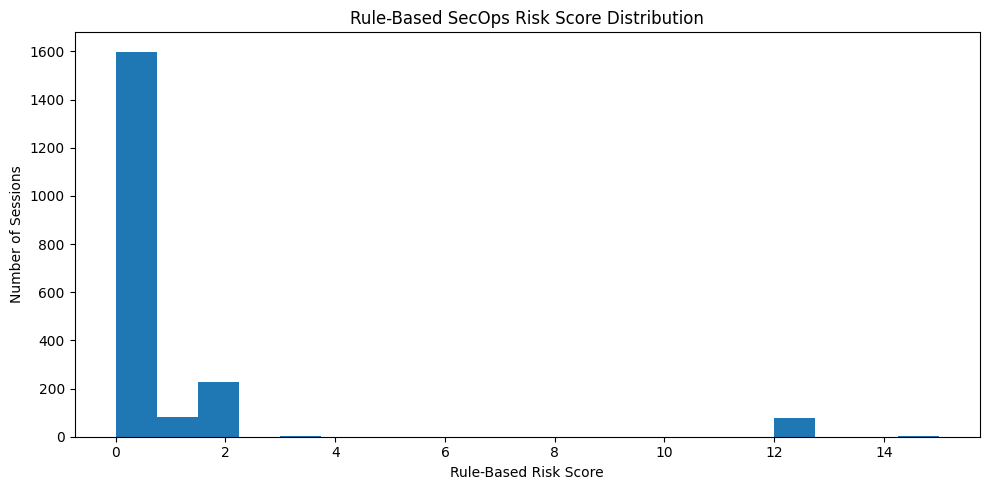

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/rule_based_risk_score_distribution.png


In [101]:
# ============================================================
# Step 6: Visualize rule-based risk score distribution
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(risk_df["rule_risk_score"], bins=20)
plt.title("Rule-Based SecOps Risk Score Distribution")
plt.xlabel("Rule-Based Risk Score")
plt.ylabel("Number of Sessions")
plt.tight_layout()

rule_score_fig_path = FIGURE_DIR / "rule_based_risk_score_distribution.png"
plt.savefig(rule_score_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", rule_score_fig_path)

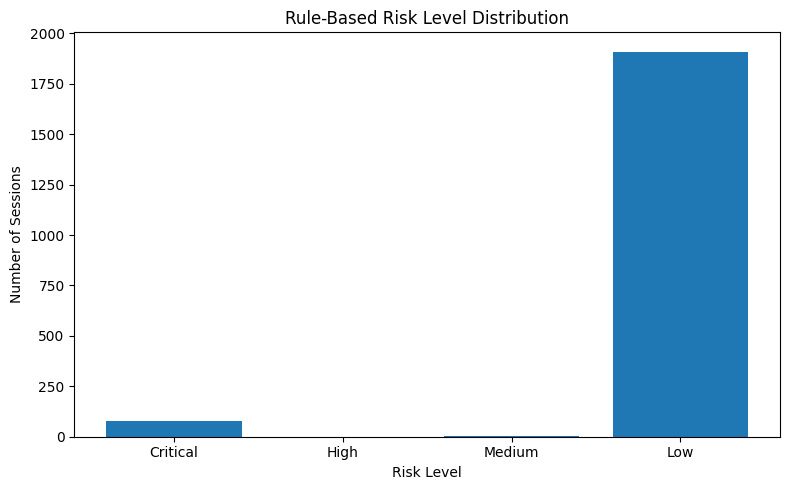

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/rule_based_risk_level_distribution.png


In [102]:
# ============================================================
# Step 6: Visualize rule-based risk level distribution
# ============================================================

risk_level_order = ["Critical", "High", "Medium", "Low"]
risk_level_counts = risk_df["rule_risk_level"].value_counts().reindex(risk_level_order).fillna(0)

plt.figure(figsize=(8, 5))
plt.bar(risk_level_counts.index, risk_level_counts.values)
plt.title("Rule-Based Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Sessions")
plt.tight_layout()

rule_level_fig_path = FIGURE_DIR / "rule_based_risk_level_distribution.png"
plt.savefig(rule_level_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", rule_level_fig_path)

In [103]:
# ============================================================
# Step 6: Save top rule-based risky sessions
# ============================================================

top_rule_risky_sessions = risk_df.sort_values(
    by="rule_risk_score",
    ascending=False
).head(50)

top_rule_risky_sessions_path = RESULTS_DIR / "top_rule_based_risky_sessions.csv"
risk_df_path = RESULTS_DIR / "rule_based_risk_scored_sessions.csv"

top_rule_risky_sessions.to_csv(top_rule_risky_sessions_path, index=False)
risk_df.to_csv(risk_df_path, index=False)

print("Saved top risky sessions:", top_rule_risky_sessions_path)
print("Saved full rule-scored sessions:", risk_df_path)

display(top_rule_risky_sessions[
    [
        "block_id",
        "rule_risk_level",
        "rule_risk_score",
        "warn_count",
        "exception_keyword_count",
        "delete_keyword_count",
        "event_sequence",
        "rule_risk_reason"
    ]
].head(20))

Saved top risky sessions: secops_log_anomaly_triage_hdfs/results/top_rule_based_risky_sessions.csv
Saved full rule-scored sessions: secops_log_anomaly_triage_hdfs/results/rule_based_risk_scored_sessions.csv


,block_id,rule_risk_level,rule_risk_score,warn_count,exception_keyword_count,delete_keyword_count,event_sequence,rule_risk_reason
694,blk_-7029628814943626474,Critical,15,1,1,0,E11 -> E3,contains WARN-level log; contains exception/er...
1897,blk_8478683141242372735,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
349,blk_-4181768899028058192,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
1894,blk_8466246428293623262,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
61,blk_-1508527605812345693,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
1780,blk_7517964792804498202,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
487,blk_-5340885607150360719,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
1813,blk_7760079751081658559,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
672,blk_-6900989714336081087,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...
649,blk_-667933171485085225,Critical,12,1,1,0,E3,contains WARN-level log; contains exception/er...


In [104]:
# ============================================================
# Step 6: Save rule-based risk summary
# ============================================================

rule_risk_summary = {
    "total_sessions": int(len(risk_df)),
    "critical_sessions": int((risk_df["rule_risk_level"] == "Critical").sum()),
    "high_sessions": int((risk_df["rule_risk_level"] == "High").sum()),
    "medium_sessions": int((risk_df["rule_risk_level"] == "Medium").sum()),
    "low_sessions": int((risk_df["rule_risk_level"] == "Low").sum()),
    "max_rule_risk_score": int(risk_df["rule_risk_score"].max()),
    "average_rule_risk_score": float(round(risk_df["rule_risk_score"].mean(), 4))
}

rule_risk_summary_path = RESULTS_DIR / "rule_based_risk_summary.json"

with open(rule_risk_summary_path, "w") as f:
    json.dump(rule_risk_summary, f, indent=4)

print("Rule-Based Risk Summary:")
print(json.dumps(rule_risk_summary, indent=4))

print("\nSaved:", rule_risk_summary_path)

Rule-Based Risk Summary:
{
    "total_sessions": 1994,
    "critical_sessions": 80,
    "high_sessions": 0,
    "medium_sessions": 4,
    "low_sessions": 1910,
    "max_rule_risk_score": 15,
    "average_rule_risk_score": 0.7598
}

Saved: secops_log_anomaly_triage_hdfs/results/rule_based_risk_summary.json


In [105]:
# ============================================================
# Step 7: Prepare feature matrix for Isolation Forest
# ============================================================

# Columns that should not be used as model features
exclude_from_model = [
    "block_id",
    "first_event",
    "last_event",
    "event_sequence",
    "component_sequence",
    "level_sequence",
    "rule_risk_level",
    "rule_risk_reason"
]

# Use numeric columns only
model_feature_columns = [
    col for col in risk_df.columns
    if col not in exclude_from_model
    and pd.api.types.is_numeric_dtype(risk_df[col])
]

X_model = risk_df[model_feature_columns].copy()

print("Number of model features:", len(model_feature_columns))
print("Model feature matrix shape:", X_model.shape)

display(X_model.head())

Number of model features: 37
Model feature matrix shape: (1994, 37)


,log_count,first_line_id,last_line_id,line_span,unique_event_count,unique_component_count,warn_count,info_count,has_warn,exception_keyword_count,...,event_count_E9,component_count_dfs_DataBlockScanner,component_count_dfs_DataNode,component_count_dfs_DataNode_DataXceiver,component_count_dfs_DataNode_PacketResponder,component_count_dfs_FSDataset,component_count_dfs_FSNamesystem,level_count_INFO,level_count_WARN,rule_risk_score
0,1,1853,1853,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,1,0,2
1,1,1401,1401,0,1,1,0,1,0,0,...,1,0,0,0,0,1,0,1,0,0
2,1,1700,1700,0,1,1,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
3,1,161,161,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,1,0,0
4,1,1488,1488,0,1,1,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0


In [106]:
# ============================================================
# Step 7: Scale numeric features
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_model)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (1994, 37)


In [107]:
# ============================================================
# Step 7: Train Isolation Forest
# ============================================================

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=RANDOM_STATE
)

risk_df["isolation_prediction"] = isolation_forest.fit_predict(X_scaled)

# Isolation Forest output:
# 1 = normal
# -1 = anomaly
risk_df["isolation_label"] = risk_df["isolation_prediction"].map({
    1: "normal",
    -1: "anomaly"
})

# decision_function: lower score means more anomalous
risk_df["isolation_anomaly_score"] = isolation_forest.decision_function(X_scaled)

# Convert so higher value means higher anomaly risk
risk_df["ml_anomaly_risk"] = -risk_df["isolation_anomaly_score"]

print("Isolation Forest label distribution:")
print(risk_df["isolation_label"].value_counts())

display(risk_df[
    [
        "block_id",
        "isolation_label",
        "isolation_anomaly_score",
        "ml_anomaly_risk",
        "rule_risk_level",
        "rule_risk_score",
        "event_sequence"
    ]
].sort_values("ml_anomaly_risk", ascending=False).head(20))

Isolation Forest label distribution:
isolation_label
normal     1894
anomaly     100
Name: count, dtype: int64


,block_id,isolation_label,isolation_anomaly_score,ml_anomaly_risk,rule_risk_level,rule_risk_score,event_sequence
1149,blk_2262752117989012641,anomaly,-0.112690,0.112690,Critical,12,E3
349,blk_-4181768899028058192,anomaly,-0.112536,0.112536,Critical,12,E3
234,blk_-3140031507252212554,anomaly,-0.112338,0.112338,Critical,12,E3
841,blk_-8083036675630459841,anomaly,-0.112185,0.112185,Critical,12,E3
61,blk_-1508527605812345693,anomaly,-0.111878,0.111878,Critical,12,E3
1457,blk_481857539063371482,anomaly,-0.111528,0.111528,Critical,12,E3
694,blk_-7029628814943626474,anomaly,-0.092943,0.092943,Critical,15,E11 -> E3
215,blk_-2918118818249673980,anomaly,-0.086998,0.086998,Critical,12,E3
1882,blk_8376667364205250596,anomaly,-0.086850,0.086850,Critical,12,E3
1313,blk_3763728533434719668,anomaly,-0.086111,0.086111,Critical,12,E3


In [108]:
# ============================================================
# Step 7: Compare Isolation Forest anomalies with rule-based risk levels
# ============================================================

ml_rule_comparison = pd.crosstab(
    risk_df["rule_risk_level"],
    risk_df["isolation_label"]
)

display(ml_rule_comparison)

ml_rule_comparison.to_csv(
    RESULTS_DIR / "ml_vs_rule_risk_comparison.csv"
)

print("Saved:", RESULTS_DIR / "ml_vs_rule_risk_comparison.csv")

isolation_label,anomaly,normal
rule_risk_level,,
Critical,80,0
Low,16,1894
Medium,4,0


Saved: secops_log_anomaly_triage_hdfs/results/ml_vs_rule_risk_comparison.csv


In [109]:
# ============================================================
# Step 7: Create combined ML + rule alert category
# ============================================================

def assign_ml_rule_alert(row):
    if row["rule_risk_level"] in ["Critical", "High"] and row["isolation_label"] == "anomaly":
        return "high_confidence_alert"
    elif row["rule_risk_level"] in ["Critical", "High"]:
        return "rule_priority_alert"
    elif row["isolation_label"] == "anomaly":
        return "ml_anomaly_alert"
    elif row["rule_risk_level"] == "Medium":
        return "medium_rule_alert"
    else:
        return "normal_or_low_risk"


risk_df["ml_rule_alert_type"] = risk_df.apply(assign_ml_rule_alert, axis=1)

print("Combined ML + rule alert distribution:")
print(risk_df["ml_rule_alert_type"].value_counts())

display(risk_df[
    [
        "block_id",
        "ml_rule_alert_type",
        "rule_risk_level",
        "rule_risk_score",
        "isolation_label",
        "ml_anomaly_risk",
        "event_sequence",
        "rule_risk_reason"
    ]
].sort_values(
    by=["ml_anomaly_risk", "rule_risk_score"],
    ascending=False
).head(20))

Combined ML + rule alert distribution:
ml_rule_alert_type
normal_or_low_risk       1894
high_confidence_alert      80
ml_anomaly_alert           20
Name: count, dtype: int64


,block_id,ml_rule_alert_type,rule_risk_level,rule_risk_score,isolation_label,ml_anomaly_risk,event_sequence,rule_risk_reason
1149,blk_2262752117989012641,high_confidence_alert,Critical,12,anomaly,0.112690,E3,contains WARN-level log; contains exception/er...
349,blk_-4181768899028058192,high_confidence_alert,Critical,12,anomaly,0.112536,E3,contains WARN-level log; contains exception/er...
234,blk_-3140031507252212554,high_confidence_alert,Critical,12,anomaly,0.112338,E3,contains WARN-level log; contains exception/er...
841,blk_-8083036675630459841,high_confidence_alert,Critical,12,anomaly,0.112185,E3,contains WARN-level log; contains exception/er...
61,blk_-1508527605812345693,high_confidence_alert,Critical,12,anomaly,0.111878,E3,contains WARN-level log; contains exception/er...
1457,blk_481857539063371482,high_confidence_alert,Critical,12,anomaly,0.111528,E3,contains WARN-level log; contains exception/er...
694,blk_-7029628814943626474,high_confidence_alert,Critical,15,anomaly,0.092943,E11 -> E3,contains WARN-level log; contains exception/er...
215,blk_-2918118818249673980,high_confidence_alert,Critical,12,anomaly,0.086998,E3,contains WARN-level log; contains exception/er...
1882,blk_8376667364205250596,high_confidence_alert,Critical,12,anomaly,0.086850,E3,contains WARN-level log; contains exception/er...
1313,blk_3763728533434719668,high_confidence_alert,Critical,12,anomaly,0.086111,E3,contains WARN-level log; contains exception/er...


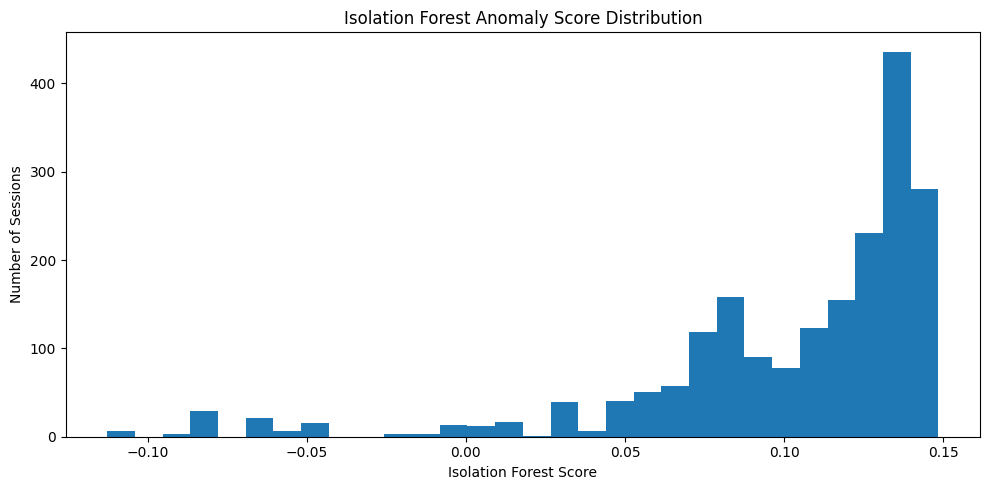

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/isolation_forest_score_distribution.png


In [110]:
# ============================================================
# Step 7: Visualize Isolation Forest anomaly score distribution
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(risk_df["isolation_anomaly_score"], bins=30)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Isolation Forest Score")
plt.ylabel("Number of Sessions")
plt.tight_layout()

isolation_score_fig_path = FIGURE_DIR / "isolation_forest_score_distribution.png"
plt.savefig(isolation_score_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", isolation_score_fig_path)

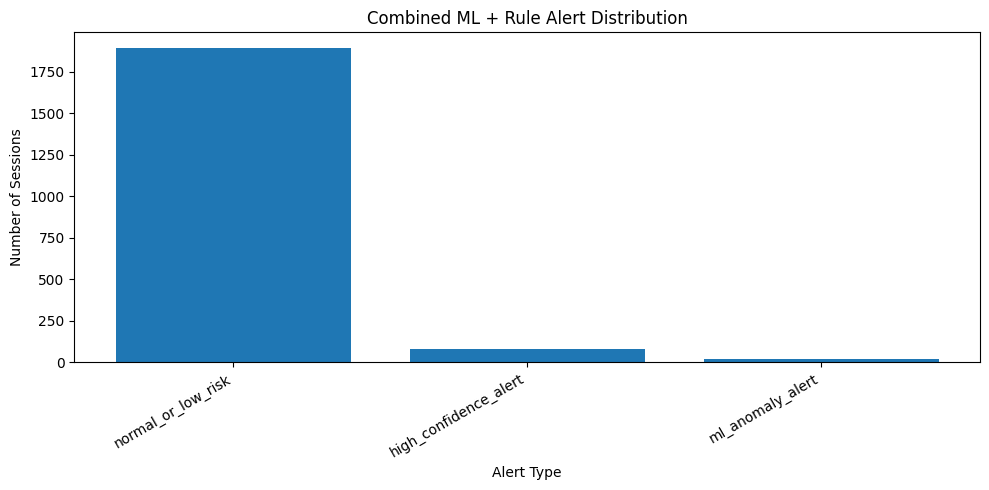

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/combined_ml_rule_alert_distribution.png


In [111]:
# ============================================================
# Step 7: Visualize combined ML + rule alert distribution
# ============================================================

alert_counts = risk_df["ml_rule_alert_type"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(alert_counts.index, alert_counts.values)
plt.title("Combined ML + Rule Alert Distribution")
plt.xlabel("Alert Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

combined_alert_fig_path = FIGURE_DIR / "combined_ml_rule_alert_distribution.png"
plt.savefig(combined_alert_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", combined_alert_fig_path)

In [112]:
# ============================================================
# Step 7: Save Isolation Forest anomaly outputs
# ============================================================

isolation_results_path = RESULTS_DIR / "isolation_forest_anomaly_results.csv"
top_ml_anomalies_path = RESULTS_DIR / "top_isolation_forest_anomalies.csv"

risk_df.to_csv(isolation_results_path, index=False)

top_ml_anomalies = risk_df.sort_values(
    by="ml_anomaly_risk",
    ascending=False
).head(50)

top_ml_anomalies.to_csv(top_ml_anomalies_path, index=False)

print("Saved Isolation Forest results:", isolation_results_path)
print("Saved top ML anomalies:", top_ml_anomalies_path)

display(top_ml_anomalies[
    [
        "block_id",
        "ml_rule_alert_type",
        "isolation_label",
        "ml_anomaly_risk",
        "rule_risk_level",
        "rule_risk_score",
        "event_sequence",
        "rule_risk_reason"
    ]
].head(20))

Saved Isolation Forest results: secops_log_anomaly_triage_hdfs/results/isolation_forest_anomaly_results.csv
Saved top ML anomalies: secops_log_anomaly_triage_hdfs/results/top_isolation_forest_anomalies.csv


,block_id,ml_rule_alert_type,isolation_label,ml_anomaly_risk,rule_risk_level,rule_risk_score,event_sequence,rule_risk_reason
1149,blk_2262752117989012641,high_confidence_alert,anomaly,0.112690,Critical,12,E3,contains WARN-level log; contains exception/er...
349,blk_-4181768899028058192,high_confidence_alert,anomaly,0.112536,Critical,12,E3,contains WARN-level log; contains exception/er...
234,blk_-3140031507252212554,high_confidence_alert,anomaly,0.112338,Critical,12,E3,contains WARN-level log; contains exception/er...
841,blk_-8083036675630459841,high_confidence_alert,anomaly,0.112185,Critical,12,E3,contains WARN-level log; contains exception/er...
61,blk_-1508527605812345693,high_confidence_alert,anomaly,0.111878,Critical,12,E3,contains WARN-level log; contains exception/er...
1457,blk_481857539063371482,high_confidence_alert,anomaly,0.111528,Critical,12,E3,contains WARN-level log; contains exception/er...
694,blk_-7029628814943626474,high_confidence_alert,anomaly,0.092943,Critical,15,E11 -> E3,contains WARN-level log; contains exception/er...
215,blk_-2918118818249673980,high_confidence_alert,anomaly,0.086998,Critical,12,E3,contains WARN-level log; contains exception/er...
1882,blk_8376667364205250596,high_confidence_alert,anomaly,0.086850,Critical,12,E3,contains WARN-level log; contains exception/er...
1313,blk_3763728533434719668,high_confidence_alert,anomaly,0.086111,Critical,12,E3,contains WARN-level log; contains exception/er...


In [113]:
# ============================================================
# Step 7: Save ML anomaly summary
# ============================================================

ml_anomaly_summary = {
    "total_sessions": int(len(risk_df)),
    "isolation_forest_normal_sessions": int((risk_df["isolation_label"] == "normal").sum()),
    "isolation_forest_anomaly_sessions": int((risk_df["isolation_label"] == "anomaly").sum()),
    "contamination_rate_used": 0.05,
    "high_confidence_alerts": int((risk_df["ml_rule_alert_type"] == "high_confidence_alert").sum()),
    "rule_priority_alerts": int((risk_df["ml_rule_alert_type"] == "rule_priority_alert").sum()),
    "ml_only_anomaly_alerts": int((risk_df["ml_rule_alert_type"] == "ml_anomaly_alert").sum()),
    "medium_rule_alerts": int((risk_df["ml_rule_alert_type"] == "medium_rule_alert").sum()),
    "normal_or_low_risk_sessions": int((risk_df["ml_rule_alert_type"] == "normal_or_low_risk").sum())
}

ml_anomaly_summary_path = RESULTS_DIR / "ml_anomaly_summary.json"

with open(ml_anomaly_summary_path, "w") as f:
    json.dump(ml_anomaly_summary, f, indent=4)

print("ML Anomaly Summary:")
print(json.dumps(ml_anomaly_summary, indent=4))

print("\nSaved:", ml_anomaly_summary_path)

ML Anomaly Summary:
{
    "total_sessions": 1994,
    "isolation_forest_normal_sessions": 1894,
    "isolation_forest_anomaly_sessions": 100,
    "contamination_rate_used": 0.05,
    "high_confidence_alerts": 80,
    "rule_priority_alerts": 0,
    "ml_only_anomaly_alerts": 20,
    "medium_rule_alerts": 0,
    "normal_or_low_risk_sessions": 1894
}

Saved: secops_log_anomaly_triage_hdfs/results/ml_anomaly_summary.json


In [114]:
# ============================================================
# Step 8: Calculate global Event ID rarity
# ============================================================

event_count_series = block_logs_df["EventId"].value_counts()
total_event_count = event_count_series.sum()

event_rarity_df = event_count_series.reset_index()
event_rarity_df.columns = ["EventId", "event_count"]

event_rarity_df["event_frequency"] = event_rarity_df["event_count"] / total_event_count

# Rarity score: lower frequency means higher rarity
event_rarity_df["event_rarity_score"] = -np.log(event_rarity_df["event_frequency"])

event_rarity_df = event_rarity_df.sort_values(
    by="event_rarity_score",
    ascending=False
).reset_index(drop=True)

display(event_rarity_df)

event_rarity_path = RESULTS_DIR / "event_rarity_scores.csv"
event_rarity_df.to_csv(event_rarity_path, index=False)

print("Saved event rarity scores:", event_rarity_path)

,EventId,event_count,event_frequency,event_rarity_score
0,E2,1,0.0005,7.600902
1,E5,1,0.0005,7.600902
2,E12,2,0.0010,6.907755
3,E4,5,0.0025,5.991465
4,E14,20,0.0100,4.605170
5,E1,80,0.0400,3.218876
6,E3,80,0.0400,3.218876
7,E7,115,0.0575,2.855970
8,E8,224,0.1120,2.189256
9,E9,263,0.1315,2.028748


Saved event rarity scores: secops_log_anomaly_triage_hdfs/results/event_rarity_scores.csv


In [115]:
# ============================================================
# Step 8: Define rare Event ID threshold
# ============================================================

rare_event_threshold = event_rarity_df["event_rarity_score"].quantile(0.75)

rare_events = event_rarity_df[
    event_rarity_df["event_rarity_score"] >= rare_event_threshold
]["EventId"].tolist()

print("Rare event threshold:", rare_event_threshold)
print("Rare Event IDs:", rare_events)

Rare event threshold: 5.644890956828009
Rare Event IDs: ['E2', 'E5', 'E12', 'E4']


In [116]:
# ============================================================
# Step 8: Add rare event features to each session
# ============================================================

event_rarity_map = dict(
    zip(
        event_rarity_df["EventId"],
        event_rarity_df["event_rarity_score"]
    )
)

def calculate_session_event_rarity(event_sequence_text):
    events = str(event_sequence_text).split(" -> ")
    rarity_scores = [event_rarity_map.get(event, 0) for event in events]

    if len(rarity_scores) == 0:
        return pd.Series({
            "mean_event_rarity": 0,
            "max_event_rarity": 0,
            "rare_event_count": 0
        })

    return pd.Series({
        "mean_event_rarity": np.mean(rarity_scores),
        "max_event_rarity": np.max(rarity_scores),
        "rare_event_count": sum(score >= rare_event_threshold for score in rarity_scores)
    })


rarity_session_features = risk_df["event_sequence"].apply(
    calculate_session_event_rarity
)

risk_df = pd.concat(
    [
        risk_df.reset_index(drop=True),
        rarity_session_features.reset_index(drop=True)
    ],
    axis=1
)

display(risk_df[
    [
        "block_id",
        "event_sequence",
        "mean_event_rarity",
        "max_event_rarity",
        "rare_event_count",
        "rule_risk_level",
        "isolation_label"
    ]
].sort_values(
    by=["rare_event_count", "max_event_rarity"],
    ascending=False
).head(20))

,block_id,event_sequence,mean_event_rarity,max_event_rarity,rare_event_count,rule_risk_level,isolation_label
769,blk_-7571492020523929240,E5,7.600902,7.600902,1.0,Low,normal
1391,blk_4292382298896622412,E2,7.600902,7.600902,1.0,Low,normal
380,blk_-4411589101766563890,E10 -> E12,4.384432,6.907755,1.0,Medium,anomaly
1045,blk_1473949624670719319,E12,6.907755,6.907755,1.0,Low,normal
460,blk_-5140072410813878235,E4,5.991465,5.991465,1.0,Low,normal
905,blk_-8570780307468499817,E4,5.991465,5.991465,1.0,Low,normal
959,blk_-9016567407076718172,E4,5.991465,5.991465,1.0,Low,normal
1357,blk_4029139044660806713,E4,5.991465,5.991465,1.0,Low,normal
1842,blk_8048594464172649365,E4,5.991465,5.991465,1.0,Low,normal
47,blk_-1383276859207001328,E14,4.605170,4.605170,0.0,Low,anomaly


In [117]:
# ============================================================
# Step 8: Analyze rare event overlap with existing alerts
# ============================================================

rare_event_alert_analysis = pd.crosstab(
    risk_df["rare_event_count"] > 0,
    risk_df["ml_rule_alert_type"]
)

display(rare_event_alert_analysis)

rare_event_alert_analysis.to_csv(
    RESULTS_DIR / "rare_event_alert_overlap.csv"
)

print("Saved:", RESULTS_DIR / "rare_event_alert_overlap.csv")

ml_rule_alert_type,high_confidence_alert,ml_anomaly_alert,normal_or_low_risk
rare_event_count,,,
False,80,19,1886
True,0,1,8


Saved: secops_log_anomaly_triage_hdfs/results/rare_event_alert_overlap.csv


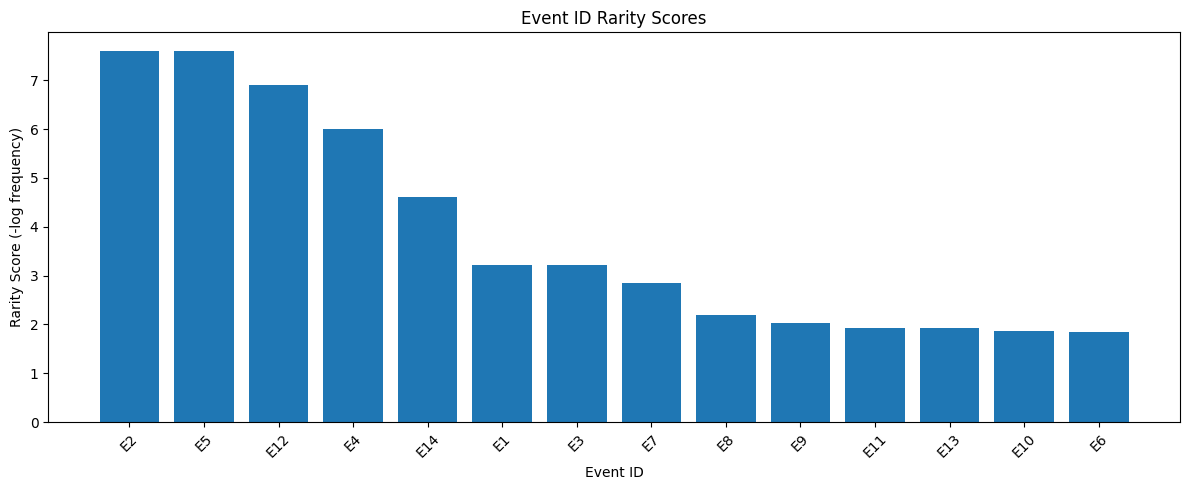

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/event_id_rarity_scores.png


In [118]:
# ============================================================
# Step 8: Visualize Event ID rarity scores
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(event_rarity_df["EventId"], event_rarity_df["event_rarity_score"])
plt.title("Event ID Rarity Scores")
plt.xlabel("Event ID")
plt.ylabel("Rarity Score (-log frequency)")
plt.xticks(rotation=45)
plt.tight_layout()

event_rarity_fig_path = FIGURE_DIR / "event_id_rarity_scores.png"
plt.savefig(event_rarity_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", event_rarity_fig_path)

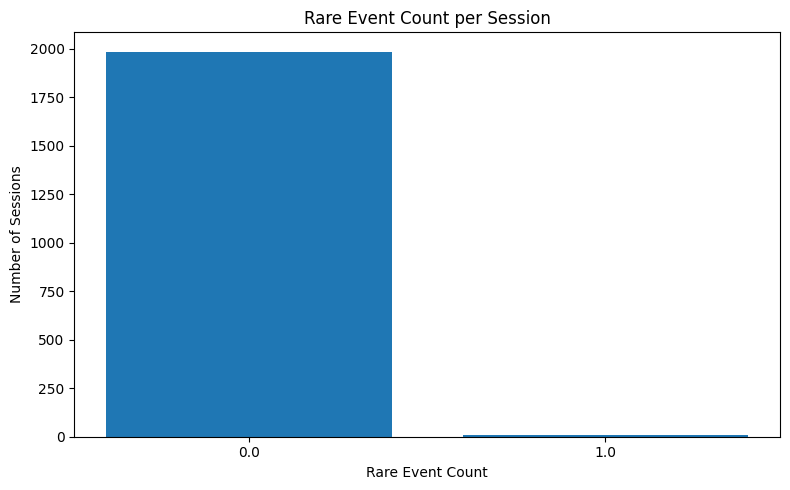

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/rare_event_count_distribution.png


In [119]:
# ============================================================
# Step 8: Visualize rare event count distribution
# ============================================================

rare_event_counts = risk_df["rare_event_count"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rare_event_counts.index.astype(str), rare_event_counts.values)
plt.title("Rare Event Count per Session")
plt.xlabel("Rare Event Count")
plt.ylabel("Number of Sessions")
plt.tight_layout()

rare_event_count_fig_path = FIGURE_DIR / "rare_event_count_distribution.png"
plt.savefig(rare_event_count_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", rare_event_count_fig_path)

In [120]:
# ============================================================
# Step 8: Save rare event enriched results
# ============================================================

rare_event_results_path = RESULTS_DIR / "rare_event_enriched_sessions.csv"

risk_df.to_csv(rare_event_results_path, index=False)

rare_event_summary = {
    "total_sessions": int(len(risk_df)),
    "rare_event_threshold": float(round(rare_event_threshold, 4)),
    "rare_event_ids": rare_events,
    "sessions_with_rare_events": int((risk_df["rare_event_count"] > 0).sum()),
    "max_rare_event_count_in_session": int(risk_df["rare_event_count"].max()),
    "average_mean_event_rarity": float(round(risk_df["mean_event_rarity"].mean(), 4)),
    "max_event_rarity_observed": float(round(risk_df["max_event_rarity"].max(), 4))
}

rare_event_summary_path = RESULTS_DIR / "rare_event_summary.json"

with open(rare_event_summary_path, "w") as f:
    json.dump(rare_event_summary, f, indent=4)

print("Rare Event Summary:")
print(json.dumps(rare_event_summary, indent=4))

print("\nSaved enriched sessions:", rare_event_results_path)
print("Saved summary:", rare_event_summary_path)

Rare Event Summary:
{
    "total_sessions": 1994,
    "rare_event_threshold": 5.6449,
    "rare_event_ids": [
        "E2",
        "E5",
        "E12",
        "E4"
    ],
    "sessions_with_rare_events": 9,
    "max_rare_event_count_in_session": 1,
    "average_mean_event_rarity": 2.1498,
    "max_event_rarity_observed": 7.6009
}

Saved enriched sessions: secops_log_anomaly_triage_hdfs/results/rare_event_enriched_sessions.csv
Saved summary: secops_log_anomaly_triage_hdfs/results/rare_event_summary.json


In [121]:
# ============================================================
# Step 9: Extract Event ID transitions from session traces
# ============================================================

def extract_event_transitions(event_sequence_text):
    """
    Convert an event sequence string into event transitions.
    Example:
    'E11 -> E3' becomes ['E11->E3']
    """
    events = str(event_sequence_text).split(" -> ")

    if len(events) < 2:
        return []

    transitions = [
        f"{events[i]}->{events[i+1]}"
        for i in range(len(events) - 1)
    ]

    return transitions


risk_df["event_transitions"] = risk_df["event_sequence"].apply(extract_event_transitions)
risk_df["transition_count"] = risk_df["event_transitions"].apply(len)

print("Transition count distribution:")
print(risk_df["transition_count"].value_counts().sort_index())

display(risk_df[
    [
        "block_id",
        "event_sequence",
        "event_transitions",
        "transition_count",
        "rule_risk_level",
        "isolation_label"
    ]
].sort_values("transition_count", ascending=False).head(15))

Transition count distribution:
transition_count
0    1988
1       6
Name: count, dtype: int64


,block_id,event_sequence,event_transitions,transition_count,rule_risk_level,isolation_label
694,blk_-7029628814943626474,E11 -> E3,[E11->E3],1,Critical,anomaly
1729,blk_707166530951154301,E10 -> E6,[E10->E6],1,Medium,anomaly
924,blk_-8775602795571523802,E9 -> E9,[E9->E9],1,Low,normal
380,blk_-4411589101766563890,E10 -> E12,[E10->E12],1,Medium,anomaly
1912,blk_8596624696139957935,E13 -> E7,[E13->E7],1,Medium,anomaly
1647,blk_6400082566804273401,E7 -> E13,[E7->E13],1,Medium,anomaly
1335,blk_3894335463008345041,E14,[],0,Low,normal
1334,blk_38865049064139660,E10,[],0,Low,normal
1333,blk_3876184938151091897,E8,[],0,Low,normal
1332,blk_387577766066135394,E7,[],0,Low,normal


In [122]:
# ============================================================
# Step 9: Extract Event ID transitions from session traces
# ============================================================

def extract_event_transitions(event_sequence_text):
    """
    Convert an event sequence string into event transitions.
    Example:
    'E11 -> E3' becomes ['E11->E3']
    """
    events = str(event_sequence_text).split(" -> ")

    if len(events) < 2:
        return []

    transitions = [
        f"{events[i]}->{events[i+1]}"
        for i in range(len(events) - 1)
    ]

    return transitions


risk_df["event_transitions"] = risk_df["event_sequence"].apply(extract_event_transitions)
risk_df["transition_count"] = risk_df["event_transitions"].apply(len)

print("Transition count distribution:")
print(risk_df["transition_count"].value_counts().sort_index())

display(risk_df[
    [
        "block_id",
        "event_sequence",
        "event_transitions",
        "transition_count",
        "rule_risk_level",
        "isolation_label"
    ]
].sort_values("transition_count", ascending=False).head(15))

Transition count distribution:
transition_count
0    1988
1       6
Name: count, dtype: int64


,block_id,event_sequence,event_transitions,transition_count,rule_risk_level,isolation_label
694,blk_-7029628814943626474,E11 -> E3,[E11->E3],1,Critical,anomaly
1729,blk_707166530951154301,E10 -> E6,[E10->E6],1,Medium,anomaly
924,blk_-8775602795571523802,E9 -> E9,[E9->E9],1,Low,normal
380,blk_-4411589101766563890,E10 -> E12,[E10->E12],1,Medium,anomaly
1912,blk_8596624696139957935,E13 -> E7,[E13->E7],1,Medium,anomaly
1647,blk_6400082566804273401,E7 -> E13,[E7->E13],1,Medium,anomaly
1335,blk_3894335463008345041,E14,[],0,Low,normal
1334,blk_38865049064139660,E10,[],0,Low,normal
1333,blk_3876184938151091897,E8,[],0,Low,normal
1332,blk_387577766066135394,E7,[],0,Low,normal


In [123]:
# ============================================================
# Step 9: Calculate transition rarity
# ============================================================

all_transitions = []

for transitions in risk_df["event_transitions"]:
    all_transitions.extend(transitions)

transition_count_series = pd.Series(all_transitions).value_counts()

if len(transition_count_series) == 0:
    print("No transitions found in the dataset.")
    transition_rarity_df = pd.DataFrame(
        columns=["transition", "transition_count", "transition_frequency", "transition_rarity_score"]
    )
else:
    total_transition_count = transition_count_series.sum()

    transition_rarity_df = transition_count_series.reset_index()
    transition_rarity_df.columns = ["transition", "transition_count"]

    transition_rarity_df["transition_frequency"] = (
        transition_rarity_df["transition_count"] / total_transition_count
    )

    transition_rarity_df["transition_rarity_score"] = -np.log(
        transition_rarity_df["transition_frequency"]
    )

    transition_rarity_df = transition_rarity_df.sort_values(
        by="transition_rarity_score",
        ascending=False
    ).reset_index(drop=True)

display(transition_rarity_df)

transition_rarity_path = RESULTS_DIR / "event_transition_rarity_scores.csv"
transition_rarity_df.to_csv(transition_rarity_path, index=False)

print("Saved transition rarity scores:", transition_rarity_path)

,transition,transition_count,transition_frequency,transition_rarity_score
0,E10->E12,1,0.166667,1.791759
1,E11->E3,1,0.166667,1.791759
2,E9->E9,1,0.166667,1.791759
3,E7->E13,1,0.166667,1.791759
4,E10->E6,1,0.166667,1.791759
5,E13->E7,1,0.166667,1.791759


Saved transition rarity scores: secops_log_anomaly_triage_hdfs/results/event_transition_rarity_scores.csv


In [124]:
# ============================================================
# Step 9: Define rare transition threshold
# ============================================================

if len(transition_rarity_df) > 0:
    rare_transition_threshold = transition_rarity_df["transition_rarity_score"].quantile(0.75)

    rare_transitions = transition_rarity_df[
        transition_rarity_df["transition_rarity_score"] >= rare_transition_threshold
    ]["transition"].tolist()
else:
    rare_transition_threshold = 0
    rare_transitions = []

print("Rare transition threshold:", rare_transition_threshold)
print("Rare transitions:", rare_transitions)

Rare transition threshold: 1.791759469228055
Rare transitions: ['E10->E12', 'E11->E3', 'E9->E9', 'E7->E13', 'E10->E6', 'E13->E7']


In [125]:
# ============================================================
# Step 9: Add transition rarity features to sessions
# ============================================================

transition_rarity_map = dict(
    zip(
        transition_rarity_df["transition"],
        transition_rarity_df["transition_rarity_score"]
    )
)

def calculate_session_transition_rarity(transitions):
    scores = [transition_rarity_map.get(transition, 0) for transition in transitions]

    if len(scores) == 0:
        return pd.Series({
            "mean_transition_rarity": 0,
            "max_transition_rarity": 0,
            "rare_transition_count": 0
        })

    return pd.Series({
        "mean_transition_rarity": np.mean(scores),
        "max_transition_rarity": np.max(scores),
        "rare_transition_count": sum(score >= rare_transition_threshold for score in scores)
    })


transition_session_features = risk_df["event_transitions"].apply(
    calculate_session_transition_rarity
)

risk_df = pd.concat(
    [
        risk_df.reset_index(drop=True),
        transition_session_features.reset_index(drop=True)
    ],
    axis=1
)

display(risk_df[
    [
        "block_id",
        "event_sequence",
        "event_transitions",
        "transition_count",
        "mean_transition_rarity",
        "max_transition_rarity",
        "rare_transition_count",
        "rule_risk_level",
        "isolation_label"
    ]
].sort_values(
    by=["rare_transition_count", "max_transition_rarity"],
    ascending=False
).head(20))

,block_id,event_sequence,event_transitions,transition_count,mean_transition_rarity,max_transition_rarity,rare_transition_count,rule_risk_level,isolation_label
380,blk_-4411589101766563890,E10 -> E12,[E10->E12],1,1.791759,1.791759,1.0,Medium,anomaly
694,blk_-7029628814943626474,E11 -> E3,[E11->E3],1,1.791759,1.791759,1.0,Critical,anomaly
924,blk_-8775602795571523802,E9 -> E9,[E9->E9],1,1.791759,1.791759,1.0,Low,normal
1647,blk_6400082566804273401,E7 -> E13,[E7->E13],1,1.791759,1.791759,1.0,Medium,anomaly
1729,blk_707166530951154301,E10 -> E6,[E10->E6],1,1.791759,1.791759,1.0,Medium,anomaly
1912,blk_8596624696139957935,E13 -> E7,[E13->E7],1,1.791759,1.791759,1.0,Medium,anomaly
0,blk_-1030832046197982436,E8,[],0,0.000000,0.000000,0.0,Low,normal
1,blk_-1046472716157313227,E9,[],0,0.000000,0.000000,0.0,Low,normal
2,blk_-1049340855430710153,E10,[],0,0.000000,0.000000,0.0,Low,normal
3,blk_-1055254430948037872,E6,[],0,0.000000,0.000000,0.0,Low,normal


In [126]:
# ============================================================
# Step 9: Add ending-risk sequence features
# ============================================================

risk_df["ends_with_e3_exception"] = risk_df["event_sequence"].apply(
    lambda x: int(str(x).split(" -> ")[-1] == "E3")
)

risk_df["starts_normal_ends_exception"] = risk_df["event_sequence"].apply(
    lambda x: int(
        len(str(x).split(" -> ")) > 1 and
        str(x).split(" -> ")[-1] == "E3"
    )
)

display(risk_df[
    [
        "block_id",
        "event_sequence",
        "ends_with_e3_exception",
        "starts_normal_ends_exception",
        "rule_risk_level",
        "isolation_label",
        "ml_rule_alert_type"
    ]
].sort_values(
    by=["starts_normal_ends_exception", "ends_with_e3_exception"],
    ascending=False
).head(20))

,block_id,event_sequence,ends_with_e3_exception,starts_normal_ends_exception,rule_risk_level,isolation_label,ml_rule_alert_type
694,blk_-7029628814943626474,E11 -> E3,1,1,Critical,anomaly,high_confidence_alert
44,blk_-1367876730256254709,E3,1,0,Critical,anomaly,high_confidence_alert
61,blk_-1508527605812345693,E3,1,0,Critical,anomaly,high_confidence_alert
108,blk_-1851265222873801714,E3,1,0,Critical,anomaly,high_confidence_alert
132,blk_-20269367189114433,E3,1,0,Critical,anomaly,high_confidence_alert
133,blk_-2032740670708110312,E3,1,0,Critical,anomaly,high_confidence_alert
195,blk_-272707591443354058,E3,1,0,Critical,anomaly,high_confidence_alert
215,blk_-2918118818249673980,E3,1,0,Critical,anomaly,high_confidence_alert
229,blk_-305633040016166849,E3,1,0,Critical,anomaly,high_confidence_alert
230,blk_-3056652732896088330,E3,1,0,Critical,anomaly,high_confidence_alert


In [127]:
# ============================================================
# Step 9: Analyze transition overlap with alert types
# ============================================================

transition_alert_overlap = pd.crosstab(
    risk_df["transition_count"] > 0,
    risk_df["ml_rule_alert_type"]
)

display(transition_alert_overlap)

transition_alert_overlap.to_csv(
    RESULTS_DIR / "transition_alert_overlap.csv"
)

print("Saved:", RESULTS_DIR / "transition_alert_overlap.csv")

ml_rule_alert_type,high_confidence_alert,ml_anomaly_alert,normal_or_low_risk
transition_count,,,
False,79,16,1893
True,1,4,1


Saved: secops_log_anomaly_triage_hdfs/results/transition_alert_overlap.csv


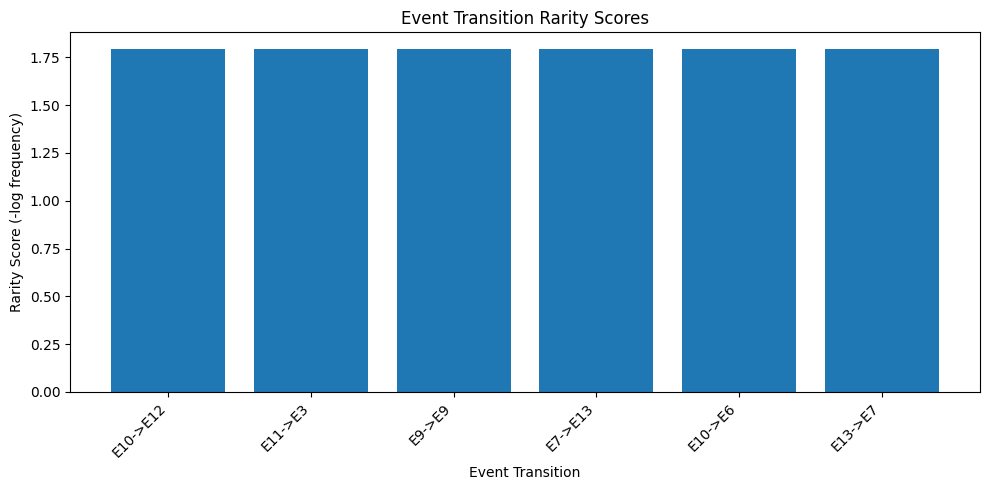

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/event_transition_rarity_scores.png


In [128]:
# ============================================================
# Step 9: Visualize transition rarity scores
# ============================================================

if len(transition_rarity_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(
        transition_rarity_df["transition"],
        transition_rarity_df["transition_rarity_score"]
    )
    plt.title("Event Transition Rarity Scores")
    plt.xlabel("Event Transition")
    plt.ylabel("Rarity Score (-log frequency)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    transition_rarity_fig_path = FIGURE_DIR / "event_transition_rarity_scores.png"
    plt.savefig(transition_rarity_fig_path, dpi=200, bbox_inches="tight")

    plt.show()

    print("Saved figure:", transition_rarity_fig_path)
else:
    print("No transition rarity plot generated because no transitions were found.")

In [129]:
# ============================================================
# Step 9: Save transition-enriched results
# ============================================================

transition_results_path = RESULTS_DIR / "transition_enriched_sessions.csv"

risk_df.to_csv(transition_results_path, index=False)

transition_summary = {
    "total_sessions": int(len(risk_df)),
    "sessions_with_transitions": int((risk_df["transition_count"] > 0).sum()),
    "unique_transitions": int(len(transition_rarity_df)),
    "rare_transition_threshold": float(round(rare_transition_threshold, 4)),
    "rare_transitions": rare_transitions,
    "sessions_with_rare_transitions": int((risk_df["rare_transition_count"] > 0).sum()),
    "sessions_ending_with_e3_exception": int(risk_df["ends_with_e3_exception"].sum()),
    "sessions_starting_normal_ending_exception": int(risk_df["starts_normal_ends_exception"].sum())
}

transition_summary_path = RESULTS_DIR / "transition_rarity_summary.json"

with open(transition_summary_path, "w") as f:
    json.dump(transition_summary, f, indent=4)

print("Transition Rarity Summary:")
print(json.dumps(transition_summary, indent=4))

print("\nSaved enriched sessions:", transition_results_path)
print("Saved summary:", transition_summary_path)

Transition Rarity Summary:
{
    "total_sessions": 1994,
    "sessions_with_transitions": 6,
    "unique_transitions": 6,
    "rare_transition_threshold": 1.7918,
    "rare_transitions": [
        "E10->E12",
        "E11->E3",
        "E9->E9",
        "E7->E13",
        "E10->E6",
        "E13->E7"
    ],
    "sessions_with_rare_transitions": 6,
    "sessions_ending_with_e3_exception": 80,
    "sessions_starting_normal_ending_exception": 1
}

Saved enriched sessions: secops_log_anomaly_triage_hdfs/results/transition_enriched_sessions.csv
Saved summary: secops_log_anomaly_triage_hdfs/results/transition_rarity_summary.json


In [130]:
# ============================================================
# Step 10: Select hybrid risk components
# ============================================================

hybrid_df = risk_df.copy()

# Ensure required columns exist
required_hybrid_columns = [
    "rule_risk_score",
    "ml_anomaly_risk",
    "max_event_rarity",
    "rare_event_count",
    "max_transition_rarity",
    "rare_transition_count",
    "ends_with_e3_exception",
    "starts_normal_ends_exception"
]

for col in required_hybrid_columns:
    if col not in hybrid_df.columns:
        hybrid_df[col] = 0

hybrid_components = required_hybrid_columns.copy()

print("Hybrid risk components:")
for col in hybrid_components:
    print("-", col)

display(hybrid_df[
    [
        "block_id",
        "event_sequence",
        "rule_risk_score",
        "ml_anomaly_risk",
        "max_event_rarity",
        "rare_event_count",
        "max_transition_rarity",
        "rare_transition_count",
        "ends_with_e3_exception",
        "starts_normal_ends_exception"
    ]
].head())

Hybrid risk components:
- rule_risk_score
- ml_anomaly_risk
- max_event_rarity
- rare_event_count
- max_transition_rarity
- rare_transition_count
- ends_with_e3_exception
- starts_normal_ends_exception


,block_id,event_sequence,rule_risk_score,ml_anomaly_risk,max_event_rarity,rare_event_count,max_transition_rarity,rare_transition_count,ends_with_e3_exception,starts_normal_ends_exception
0,blk_-1030832046197982436,E8,2,-0.033174,2.189256,0.0,0.0,0.0,0,0
1,blk_-1046472716157313227,E9,0,-0.130172,2.028748,0.0,0.0,0.0,0,0
2,blk_-1049340855430710153,E10,0,-0.124377,1.861110,0.0,0.0,0.0,0,0
3,blk_-1055254430948037872,E6,0,-0.098954,1.851509,0.0,0.0,0.0,0,0
4,blk_-1067234447809438340,E10,0,-0.139359,1.861110,0.0,0.0,0.0,0,0


In [131]:
# ============================================================
# Step 10: Normalize hybrid risk components
# ============================================================

hybrid_component_values = hybrid_df[hybrid_components].fillna(0).copy()

hybrid_scaler = MinMaxScaler()

scaled_hybrid_values = hybrid_scaler.fit_transform(hybrid_component_values)

scaled_hybrid_df = pd.DataFrame(
    scaled_hybrid_values,
    columns=[f"scaled_{col}" for col in hybrid_components]
)

hybrid_df = pd.concat(
    [
        hybrid_df.reset_index(drop=True),
        scaled_hybrid_df.reset_index(drop=True)
    ],
    axis=1
)

display(hybrid_df[
    ["block_id"] + [f"scaled_{col}" for col in hybrid_components]
].head())

,block_id,scaled_rule_risk_score,scaled_ml_anomaly_risk,scaled_max_event_rarity,scaled_rare_event_count,scaled_max_transition_rarity,scaled_rare_transition_count,scaled_ends_with_e3_exception,scaled_starts_normal_ends_exception
0,blk_-1030832046197982436,0.133333,0.441445,0.058745,0.0,0.0,0.0,0.0,0.0
1,blk_-1046472716157313227,0.000000,0.070006,0.030827,0.0,0.0,0.0,0.0,0.0
2,blk_-1049340855430710153,0.000000,0.092200,0.001670,0.0,0.0,0.0,0.0,0.0
3,blk_-1055254430948037872,0.000000,0.189553,0.000000,0.0,0.0,0.0,0.0,0.0
4,blk_-1067234447809438340,0.000000,0.034830,0.001670,0.0,0.0,0.0,0.0,0.0


In [132]:
# ============================================================
# Step 10: Create weighted hybrid SecOps risk score
# ============================================================

HYBRID_RISK_WEIGHTS = {
    "scaled_rule_risk_score": 0.35,
    "scaled_ml_anomaly_risk": 0.25,
    "scaled_max_event_rarity": 0.10,
    "scaled_rare_event_count": 0.10,
    "scaled_max_transition_rarity": 0.08,
    "scaled_rare_transition_count": 0.07,
    "scaled_ends_with_e3_exception": 0.03,
    "scaled_starts_normal_ends_exception": 0.02
}

# Initialize score
hybrid_df["hybrid_risk_score"] = 0

for feature, weight in HYBRID_RISK_WEIGHTS.items():
    if feature in hybrid_df.columns:
        hybrid_df["hybrid_risk_score"] += hybrid_df[feature] * weight

print("Hybrid risk weights:")
for feature, weight in HYBRID_RISK_WEIGHTS.items():
    print(f"{feature}: {weight}")

display(hybrid_df[
    [
        "block_id",
        "event_sequence",
        "rule_risk_score",
        "rule_risk_level",
        "isolation_label",
        "ml_anomaly_risk",
        "rare_event_count",
        "rare_transition_count",
        "hybrid_risk_score"
    ]
].sort_values("hybrid_risk_score", ascending=False).head(20))

Hybrid risk weights:
scaled_rule_risk_score: 0.35
scaled_ml_anomaly_risk: 0.25
scaled_max_event_rarity: 0.1
scaled_rare_event_count: 0.1
scaled_max_transition_rarity: 0.08
scaled_rare_transition_count: 0.07
scaled_ends_with_e3_exception: 0.03
scaled_starts_normal_ends_exception: 0.02


,block_id,event_sequence,rule_risk_score,rule_risk_level,isolation_label,ml_anomaly_risk,rare_event_count,rare_transition_count,hybrid_risk_score
694,blk_-7029628814943626474,E11 -> E3,15,Critical,anomaly,0.092943,0.0,1.0,0.804879
1149,blk_2262752117989012641,E3,12,Critical,anomaly,0.112690,0.0,0.0,0.583783
349,blk_-4181768899028058192,E3,12,Critical,anomaly,0.112536,0.0,0.0,0.583636
234,blk_-3140031507252212554,E3,12,Critical,anomaly,0.112338,0.0,0.0,0.583446
841,blk_-8083036675630459841,E3,12,Critical,anomaly,0.112185,0.0,0.0,0.583300
61,blk_-1508527605812345693,E3,12,Critical,anomaly,0.111878,0.0,0.0,0.583006
1457,blk_481857539063371482,E3,12,Critical,anomaly,0.111528,0.0,0.0,0.582671
380,blk_-4411589101766563890,E10 -> E12,3,Medium,anomaly,0.013860,1.0,1.0,0.563332
215,blk_-2918118818249673980,E3,12,Critical,anomaly,0.086998,0.0,0.0,0.559187
1882,blk_8376667364205250596,E3,12,Critical,anomaly,0.086850,0.0,0.0,0.559046


In [133]:
# ============================================================
# Step 10: Assign final severity level
# ============================================================

def assign_final_severity(score):
    if score >= 0.70:
        return "Critical"
    elif score >= 0.45:
        return "High"
    elif score >= 0.20:
        return "Medium"
    else:
        return "Low"


hybrid_df["final_severity"] = hybrid_df["hybrid_risk_score"].apply(assign_final_severity)

print("Final severity distribution:")
print(hybrid_df["final_severity"].value_counts())

display(hybrid_df[
    [
        "block_id",
        "final_severity",
        "hybrid_risk_score",
        "rule_risk_level",
        "rule_risk_score",
        "isolation_label",
        "ml_anomaly_risk",
        "event_sequence",
        "rare_event_count",
        "rare_transition_count"
    ]
].sort_values("hybrid_risk_score", ascending=False).head(25))

Final severity distribution:
final_severity
Low         1897
High          80
Medium        16
Critical       1
Name: count, dtype: int64


,block_id,final_severity,hybrid_risk_score,rule_risk_level,rule_risk_score,isolation_label,ml_anomaly_risk,event_sequence,rare_event_count,rare_transition_count
694,blk_-7029628814943626474,Critical,0.804879,Critical,15,anomaly,0.092943,E11 -> E3,0.0,1.0
1149,blk_2262752117989012641,High,0.583783,Critical,12,anomaly,0.112690,E3,0.0,0.0
349,blk_-4181768899028058192,High,0.583636,Critical,12,anomaly,0.112536,E3,0.0,0.0
234,blk_-3140031507252212554,High,0.583446,Critical,12,anomaly,0.112338,E3,0.0,0.0
841,blk_-8083036675630459841,High,0.583300,Critical,12,anomaly,0.112185,E3,0.0,0.0
61,blk_-1508527605812345693,High,0.583006,Critical,12,anomaly,0.111878,E3,0.0,0.0
1457,blk_481857539063371482,High,0.582671,Critical,12,anomaly,0.111528,E3,0.0,0.0
380,blk_-4411589101766563890,High,0.563332,Medium,3,anomaly,0.013860,E10 -> E12,1.0,1.0
215,blk_-2918118818249673980,High,0.559187,Critical,12,anomaly,0.086998,E3,0.0,0.0
1882,blk_8376667364205250596,High,0.559046,Critical,12,anomaly,0.086850,E3,0.0,0.0


In [134]:
# ============================================================
# Step 10: Assign final alert type
# ============================================================

def assign_final_alert_type(row):
    if row["final_severity"] == "Critical" and row["isolation_label"] == "anomaly":
        return "critical_confirmed_anomaly"
    elif row["final_severity"] in ["Critical", "High"] and row["rule_risk_level"] in ["Critical", "High"]:
        return "rule_driven_high_risk"
    elif row["isolation_label"] == "anomaly" and row["rare_event_count"] > 0:
        return "rare_event_ml_anomaly"
    elif row["isolation_label"] == "anomaly":
        return "ml_detected_anomaly"
    elif row["rare_event_count"] > 0 or row["rare_transition_count"] > 0:
        return "rare_pattern_watchlist"
    else:
        return "normal_or_low_priority"


hybrid_df["final_alert_type"] = hybrid_df.apply(assign_final_alert_type, axis=1)

print("Final alert type distribution:")
print(hybrid_df["final_alert_type"].value_counts())

display(hybrid_df[
    [
        "block_id",
        "final_alert_type",
        "final_severity",
        "hybrid_risk_score",
        "rule_risk_level",
        "isolation_label",
        "event_sequence",
        "rare_event_count",
        "rare_transition_count"
    ]
].sort_values("hybrid_risk_score", ascending=False).head(25))

Final alert type distribution:
final_alert_type
normal_or_low_priority        1885
rule_driven_high_risk           79
ml_detected_anomaly             19
rare_pattern_watchlist           9
rare_event_ml_anomaly            1
critical_confirmed_anomaly       1
Name: count, dtype: int64


,block_id,final_alert_type,final_severity,hybrid_risk_score,rule_risk_level,isolation_label,event_sequence,rare_event_count,rare_transition_count
694,blk_-7029628814943626474,critical_confirmed_anomaly,Critical,0.804879,Critical,anomaly,E11 -> E3,0.0,1.0
1149,blk_2262752117989012641,rule_driven_high_risk,High,0.583783,Critical,anomaly,E3,0.0,0.0
349,blk_-4181768899028058192,rule_driven_high_risk,High,0.583636,Critical,anomaly,E3,0.0,0.0
234,blk_-3140031507252212554,rule_driven_high_risk,High,0.583446,Critical,anomaly,E3,0.0,0.0
841,blk_-8083036675630459841,rule_driven_high_risk,High,0.583300,Critical,anomaly,E3,0.0,0.0
61,blk_-1508527605812345693,rule_driven_high_risk,High,0.583006,Critical,anomaly,E3,0.0,0.0
1457,blk_481857539063371482,rule_driven_high_risk,High,0.582671,Critical,anomaly,E3,0.0,0.0
380,blk_-4411589101766563890,rare_event_ml_anomaly,High,0.563332,Medium,anomaly,E10 -> E12,1.0,1.0
215,blk_-2918118818249673980,rule_driven_high_risk,High,0.559187,Critical,anomaly,E3,0.0,0.0
1882,blk_8376667364205250596,rule_driven_high_risk,High,0.559046,Critical,anomaly,E3,0.0,0.0


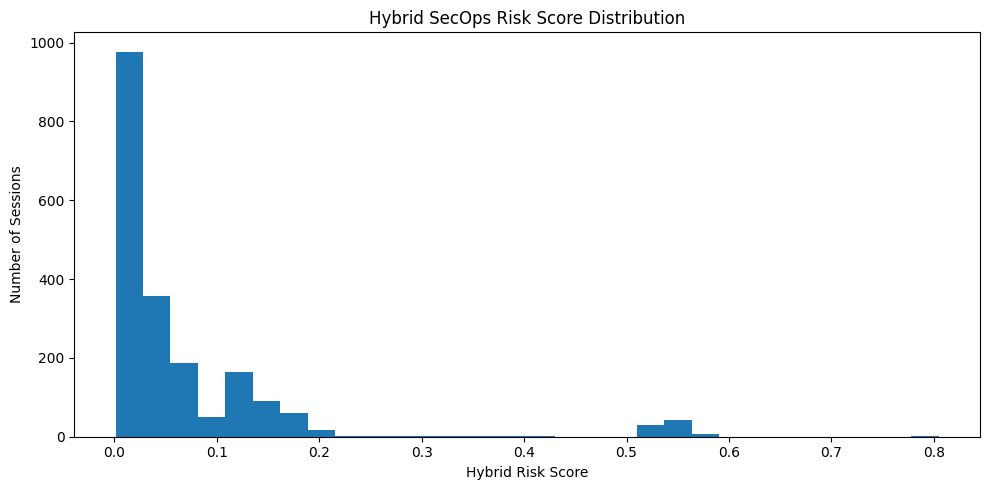

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/hybrid_secops_risk_score_distribution.png


In [135]:
# ============================================================
# Step 10: Visualize hybrid risk score distribution
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(hybrid_df["hybrid_risk_score"], bins=30)
plt.title("Hybrid SecOps Risk Score Distribution")
plt.xlabel("Hybrid Risk Score")
plt.ylabel("Number of Sessions")
plt.tight_layout()

hybrid_score_fig_path = FIGURE_DIR / "hybrid_secops_risk_score_distribution.png"
plt.savefig(hybrid_score_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", hybrid_score_fig_path)

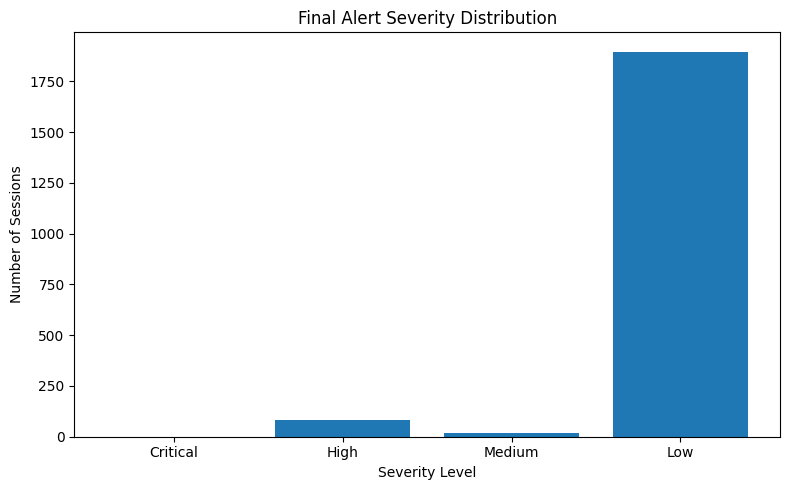

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/final_alert_severity_distribution.png


In [136]:
# ============================================================
# Step 10: Visualize final severity distribution
# ============================================================

severity_order = ["Critical", "High", "Medium", "Low"]

severity_counts = hybrid_df["final_severity"].value_counts().reindex(
    severity_order
).fillna(0)

plt.figure(figsize=(8, 5))
plt.bar(severity_counts.index, severity_counts.values)
plt.title("Final Alert Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Sessions")
plt.tight_layout()

severity_fig_path = FIGURE_DIR / "final_alert_severity_distribution.png"
plt.savefig(severity_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", severity_fig_path)

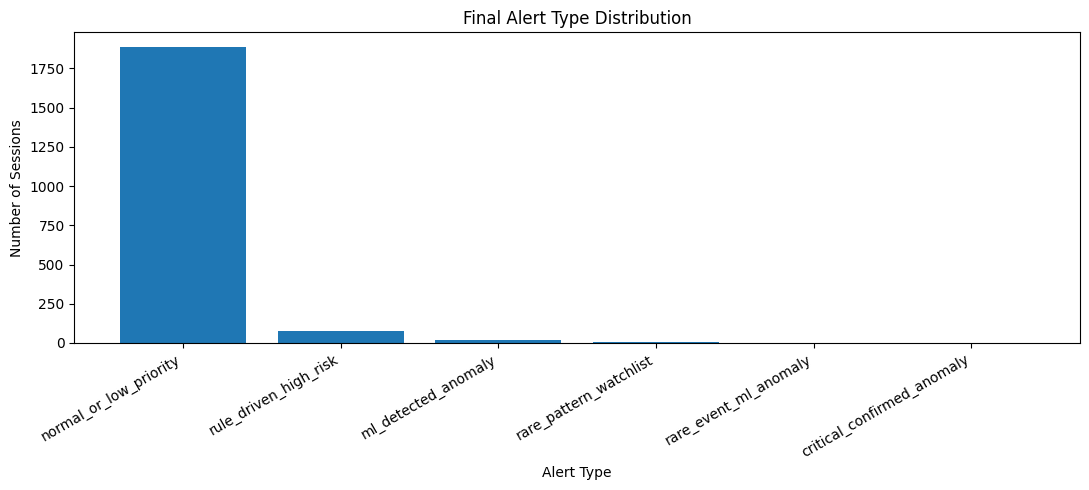

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/final_alert_type_distribution.png


In [137]:
# ============================================================
# Step 10: Visualize final alert type distribution
# ============================================================

alert_type_counts = hybrid_df["final_alert_type"].value_counts()

plt.figure(figsize=(11, 5))
plt.bar(alert_type_counts.index, alert_type_counts.values)
plt.title("Final Alert Type Distribution")
plt.xlabel("Alert Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

alert_type_fig_path = FIGURE_DIR / "final_alert_type_distribution.png"
plt.savefig(alert_type_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", alert_type_fig_path)

In [138]:
# ============================================================
# Step 10: Save hybrid risk outputs
# ============================================================

hybrid_results_path = RESULTS_DIR / "hybrid_secops_risk_scored_sessions.csv"
top_hybrid_alerts_path = RESULTS_DIR / "top_hybrid_secops_alerts.csv"

hybrid_df.to_csv(hybrid_results_path, index=False)

top_hybrid_alerts = hybrid_df.sort_values(
    by="hybrid_risk_score",
    ascending=False
).head(50)

top_hybrid_alerts.to_csv(top_hybrid_alerts_path, index=False)

print("Saved hybrid risk scored sessions:", hybrid_results_path)
print("Saved top hybrid alerts:", top_hybrid_alerts_path)

display(top_hybrid_alerts[
    [
        "block_id",
        "final_severity",
        "final_alert_type",
        "hybrid_risk_score",
        "rule_risk_score",
        "rule_risk_level",
        "isolation_label",
        "ml_anomaly_risk",
        "event_sequence",
        "rare_event_count",
        "rare_transition_count"
    ]
].head(25))

Saved hybrid risk scored sessions: secops_log_anomaly_triage_hdfs/results/hybrid_secops_risk_scored_sessions.csv
Saved top hybrid alerts: secops_log_anomaly_triage_hdfs/results/top_hybrid_secops_alerts.csv


,block_id,final_severity,final_alert_type,hybrid_risk_score,rule_risk_score,rule_risk_level,isolation_label,ml_anomaly_risk,event_sequence,rare_event_count,rare_transition_count
694,blk_-7029628814943626474,Critical,critical_confirmed_anomaly,0.804879,15,Critical,anomaly,0.092943,E11 -> E3,0.0,1.0
1149,blk_2262752117989012641,High,rule_driven_high_risk,0.583783,12,Critical,anomaly,0.112690,E3,0.0,0.0
349,blk_-4181768899028058192,High,rule_driven_high_risk,0.583636,12,Critical,anomaly,0.112536,E3,0.0,0.0
234,blk_-3140031507252212554,High,rule_driven_high_risk,0.583446,12,Critical,anomaly,0.112338,E3,0.0,0.0
841,blk_-8083036675630459841,High,rule_driven_high_risk,0.583300,12,Critical,anomaly,0.112185,E3,0.0,0.0
61,blk_-1508527605812345693,High,rule_driven_high_risk,0.583006,12,Critical,anomaly,0.111878,E3,0.0,0.0
1457,blk_481857539063371482,High,rule_driven_high_risk,0.582671,12,Critical,anomaly,0.111528,E3,0.0,0.0
380,blk_-4411589101766563890,High,rare_event_ml_anomaly,0.563332,3,Medium,anomaly,0.013860,E10 -> E12,1.0,1.0
215,blk_-2918118818249673980,High,rule_driven_high_risk,0.559187,12,Critical,anomaly,0.086998,E3,0.0,0.0
1882,blk_8376667364205250596,High,rule_driven_high_risk,0.559046,12,Critical,anomaly,0.086850,E3,0.0,0.0


In [139]:
# ============================================================
# Step 10: Save hybrid risk summary
# ============================================================

hybrid_risk_summary = {
    "total_sessions": int(len(hybrid_df)),
    "critical_sessions": int((hybrid_df["final_severity"] == "Critical").sum()),
    "high_sessions": int((hybrid_df["final_severity"] == "High").sum()),
    "medium_sessions": int((hybrid_df["final_severity"] == "Medium").sum()),
    "low_sessions": int((hybrid_df["final_severity"] == "Low").sum()),
    "max_hybrid_risk_score": float(round(hybrid_df["hybrid_risk_score"].max(), 4)),
    "average_hybrid_risk_score": float(round(hybrid_df["hybrid_risk_score"].mean(), 4)),
    "critical_confirmed_anomalies": int((hybrid_df["final_alert_type"] == "critical_confirmed_anomaly").sum()),
    "rare_event_ml_anomalies": int((hybrid_df["final_alert_type"] == "rare_event_ml_anomaly").sum()),
    "rare_pattern_watchlist": int((hybrid_df["final_alert_type"] == "rare_pattern_watchlist").sum())
}

hybrid_risk_summary_path = RESULTS_DIR / "hybrid_risk_summary.json"

with open(hybrid_risk_summary_path, "w") as f:
    json.dump(hybrid_risk_summary, f, indent=4)

print("Hybrid Risk Summary:")
print(json.dumps(hybrid_risk_summary, indent=4))

print("\nSaved:", hybrid_risk_summary_path)

Hybrid Risk Summary:
{
    "total_sessions": 1994,
    "critical_sessions": 1,
    "high_sessions": 80,
    "medium_sessions": 16,
    "low_sessions": 1897,
    "max_hybrid_risk_score": 0.8049,
    "average_hybrid_risk_score": 0.0697,
    "critical_confirmed_anomalies": 1,
    "rare_event_ml_anomalies": 1,
    "rare_pattern_watchlist": 9
}

Saved: secops_log_anomaly_triage_hdfs/results/hybrid_risk_summary.json


In [140]:
# ============================================================
# Step 11: Generate human-readable alert explanations
# ============================================================

def generate_alert_explanation(row):
    reasons = []

    # Rule-based reasons
    if row.get("rule_risk_score", 0) > 0:
        reasons.append(f"rule-based risk score is {row['rule_risk_score']}")

    if row.get("warn_count", 0) > 0:
        reasons.append("contains WARN-level log activity")

    if row.get("exception_keyword_count", 0) > 0:
        reasons.append("contains exception/error/failure-related text")

    if row.get("event_count_E3", 0) > 0:
        reasons.append("contains Event ID E3, associated with exception while serving an HDFS block")

    if row.get("delete_keyword_count", 0) > 0:
        reasons.append("contains delete/remove-related activity")

    if row.get("transfer_keyword_count", 0) > 0:
        reasons.append("contains transfer/send/served-related activity")

    # ML anomaly reason
    if row.get("isolation_label", "") == "anomaly":
        reasons.append("was flagged as anomalous by Isolation Forest")

    # Rare event reason
    if row.get("rare_event_count", 0) > 0:
        reasons.append(f"contains {int(row['rare_event_count'])} rare Event ID pattern(s)")

    # Transition reason
    if row.get("rare_transition_count", 0) > 0:
        reasons.append(f"contains {int(row['rare_transition_count'])} rare event transition(s)")

    if row.get("starts_normal_ends_exception", 0) > 0:
        reasons.append("starts with a non-exception event and ends with an E3 exception event")

    if row.get("ends_with_e3_exception", 0) > 0:
        reasons.append("ends with an E3 exception event")

    if len(reasons) == 0:
        return "No major suspicious indicators were detected. Session appears normal or low priority."

    return "Flagged because it " + "; ".join(reasons) + "."


hybrid_df["alert_explanation"] = hybrid_df.apply(generate_alert_explanation, axis=1)

display(hybrid_df[
    [
        "block_id",
        "final_severity",
        "final_alert_type",
        "hybrid_risk_score",
        "event_sequence",
        "alert_explanation"
    ]
].sort_values("hybrid_risk_score", ascending=False).head(15))

,block_id,final_severity,final_alert_type,hybrid_risk_score,event_sequence,alert_explanation
694,blk_-7029628814943626474,Critical,critical_confirmed_anomaly,0.804879,E11 -> E3,Flagged because it rule-based risk score is 15...
1149,blk_2262752117989012641,High,rule_driven_high_risk,0.583783,E3,Flagged because it rule-based risk score is 12...
349,blk_-4181768899028058192,High,rule_driven_high_risk,0.583636,E3,Flagged because it rule-based risk score is 12...
234,blk_-3140031507252212554,High,rule_driven_high_risk,0.583446,E3,Flagged because it rule-based risk score is 12...
841,blk_-8083036675630459841,High,rule_driven_high_risk,0.583300,E3,Flagged because it rule-based risk score is 12...
61,blk_-1508527605812345693,High,rule_driven_high_risk,0.583006,E3,Flagged because it rule-based risk score is 12...
1457,blk_481857539063371482,High,rule_driven_high_risk,0.582671,E3,Flagged because it rule-based risk score is 12...
380,blk_-4411589101766563890,High,rare_event_ml_anomaly,0.563332,E10 -> E12,Flagged because it rule-based risk score is 3;...
215,blk_-2918118818249673980,High,rule_driven_high_risk,0.559187,E3,Flagged because it rule-based risk score is 12...
1882,blk_8376667364205250596,High,rule_driven_high_risk,0.559046,E3,Flagged because it rule-based risk score is 12...


In [141]:
# ============================================================
# Step 11: Generate recommended analyst actions
# ============================================================

def recommend_analyst_action(row):
    severity = row.get("final_severity", "Low")
    alert_type = row.get("final_alert_type", "")

    if severity == "Critical":
        return (
            "Immediate investigation required. Review the full block trace, related DataNode activity, "
            "exception context, and surrounding logs before and after this session."
        )

    elif severity == "High":
        return (
            "Prioritize for analyst review. Check whether the WARN/E3 exception pattern repeats across "
            "multiple blocks or components."
        )

    elif severity == "Medium":
        if alert_type == "ml_detected_anomaly":
            return (
                "Review as ML-detected anomaly. Validate whether unusual feature patterns represent "
                "operational noise or suspicious behavior."
            )
        elif alert_type == "rare_event_ml_anomaly":
            return (
                "Review rare event behavior. Check if the rare Event ID appears in other sessions or "
                "indicates abnormal system activity."
            )
        elif alert_type == "rare_pattern_watchlist":
            return (
                "Place on watchlist. Rare event or transition pattern detected but no strong exception signal."
            )
        else:
            return "Monitor and review if similar behavior repeats."

    else:
        return "No immediate action required. Keep as low-priority monitoring record."


hybrid_df["recommended_action"] = hybrid_df.apply(recommend_analyst_action, axis=1)

display(hybrid_df[
    [
        "block_id",
        "final_severity",
        "final_alert_type",
        "hybrid_risk_score",
        "alert_explanation",
        "recommended_action"
    ]
].sort_values("hybrid_risk_score", ascending=False).head(15))

,block_id,final_severity,final_alert_type,hybrid_risk_score,alert_explanation,recommended_action
694,blk_-7029628814943626474,Critical,critical_confirmed_anomaly,0.804879,Flagged because it rule-based risk score is 15...,Immediate investigation required. Review the f...
1149,blk_2262752117989012641,High,rule_driven_high_risk,0.583783,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
349,blk_-4181768899028058192,High,rule_driven_high_risk,0.583636,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
234,blk_-3140031507252212554,High,rule_driven_high_risk,0.583446,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
841,blk_-8083036675630459841,High,rule_driven_high_risk,0.583300,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
61,blk_-1508527605812345693,High,rule_driven_high_risk,0.583006,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
1457,blk_481857539063371482,High,rule_driven_high_risk,0.582671,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
380,blk_-4411589101766563890,High,rare_event_ml_anomaly,0.563332,Flagged because it rule-based risk score is 3;...,Prioritize for analyst review. Check whether t...
215,blk_-2918118818249673980,High,rule_driven_high_risk,0.559187,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
1882,blk_8376667364205250596,High,rule_driven_high_risk,0.559046,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...


In [142]:
# ============================================================
# Step 11: Add investigation priority
# ============================================================

def assign_investigation_priority(severity):
    if severity == "Critical":
        return "P1 - Immediate"
    elif severity == "High":
        return "P2 - High Priority"
    elif severity == "Medium":
        return "P3 - Review"
    else:
        return "P4 - Monitor"


hybrid_df["investigation_priority"] = hybrid_df["final_severity"].apply(
    assign_investigation_priority
)

print("Investigation priority distribution:")
print(hybrid_df["investigation_priority"].value_counts())

display(hybrid_df[
    [
        "block_id",
        "investigation_priority",
        "final_severity",
        "final_alert_type",
        "hybrid_risk_score",
        "event_sequence"
    ]
].sort_values("hybrid_risk_score", ascending=False).head(20))

Investigation priority distribution:
investigation_priority
P4 - Monitor          1897
P2 - High Priority      80
P3 - Review             16
P1 - Immediate           1
Name: count, dtype: int64


,block_id,investigation_priority,final_severity,final_alert_type,hybrid_risk_score,event_sequence
694,blk_-7029628814943626474,P1 - Immediate,Critical,critical_confirmed_anomaly,0.804879,E11 -> E3
1149,blk_2262752117989012641,P2 - High Priority,High,rule_driven_high_risk,0.583783,E3
349,blk_-4181768899028058192,P2 - High Priority,High,rule_driven_high_risk,0.583636,E3
234,blk_-3140031507252212554,P2 - High Priority,High,rule_driven_high_risk,0.583446,E3
841,blk_-8083036675630459841,P2 - High Priority,High,rule_driven_high_risk,0.583300,E3
61,blk_-1508527605812345693,P2 - High Priority,High,rule_driven_high_risk,0.583006,E3
1457,blk_481857539063371482,P2 - High Priority,High,rule_driven_high_risk,0.582671,E3
380,blk_-4411589101766563890,P2 - High Priority,High,rare_event_ml_anomaly,0.563332,E10 -> E12
215,blk_-2918118818249673980,P2 - High Priority,High,rule_driven_high_risk,0.559187,E3
1882,blk_8376667364205250596,P2 - High Priority,High,rule_driven_high_risk,0.559046,E3


In [143]:
# ============================================================
# Step 11: Create final SecOps alert triage table
# ============================================================

final_triage_columns = [
    "block_id",
    "investigation_priority",
    "final_severity",
    "final_alert_type",
    "hybrid_risk_score",
    "rule_risk_score",
    "rule_risk_level",
    "isolation_label",
    "ml_anomaly_risk",
    "event_sequence",
    "component_sequence",
    "level_sequence",
    "warn_count",
    "exception_keyword_count",
    "delete_keyword_count",
    "rare_event_count",
    "rare_transition_count",
    "starts_normal_ends_exception",
    "alert_explanation",
    "recommended_action"
]

final_triage_columns = [
    col for col in final_triage_columns
    if col in hybrid_df.columns
]

final_alert_triage_df = hybrid_df[final_triage_columns].sort_values(
    by="hybrid_risk_score",
    ascending=False
).reset_index(drop=True)

display(final_alert_triage_df.head(25))

,block_id,investigation_priority,final_severity,final_alert_type,hybrid_risk_score,rule_risk_score,rule_risk_level,isolation_label,ml_anomaly_risk,event_sequence,component_sequence,level_sequence,warn_count,exception_keyword_count,delete_keyword_count,rare_event_count,rare_transition_count,starts_normal_ends_exception,alert_explanation,recommended_action
0,blk_-7029628814943626474,P1 - Immediate,Critical,critical_confirmed_anomaly,0.804879,15,Critical,anomaly,0.092943,E11 -> E3,dfs.DataNode$PacketResponder -> dfs.DataNode$D...,INFO -> WARN,1,1,0,0.0,1.0,1,Flagged because it rule-based risk score is 15...,Immediate investigation required. Review the f...
1,blk_2262752117989012641,P2 - High Priority,High,rule_driven_high_risk,0.583783,12,Critical,anomaly,0.112690,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
2,blk_-4181768899028058192,P2 - High Priority,High,rule_driven_high_risk,0.583636,12,Critical,anomaly,0.112536,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
3,blk_-3140031507252212554,P2 - High Priority,High,rule_driven_high_risk,0.583446,12,Critical,anomaly,0.112338,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
4,blk_-8083036675630459841,P2 - High Priority,High,rule_driven_high_risk,0.583300,12,Critical,anomaly,0.112185,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
5,blk_-1508527605812345693,P2 - High Priority,High,rule_driven_high_risk,0.583006,12,Critical,anomaly,0.111878,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
6,blk_481857539063371482,P2 - High Priority,High,rule_driven_high_risk,0.582671,12,Critical,anomaly,0.111528,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
7,blk_-4411589101766563890,P2 - High Priority,High,rare_event_ml_anomaly,0.563332,3,Medium,anomaly,0.013860,E10 -> E12,dfs.DataNode$PacketResponder -> dfs.DataNode$D...,INFO -> INFO,0,0,0,1.0,1.0,0,Flagged because it rule-based risk score is 3;...,Prioritize for analyst review. Check whether t...
8,blk_-2918118818249673980,P2 - High Priority,High,rule_driven_high_risk,0.559187,12,Critical,anomaly,0.086998,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...
9,blk_8376667364205250596,P2 - High Priority,High,rule_driven_high_risk,0.559046,12,Critical,anomaly,0.086850,E3,dfs.DataNode$DataXceiver,WARN,1,1,0,0.0,0.0,0,Flagged because it rule-based risk score is 12...,Prioritize for analyst review. Check whether t...


In [144]:
# ============================================================
# Step 11: Save final alert triage outputs
# ============================================================

final_triage_path = RESULTS_DIR / "final_secops_alert_triage_table.csv"
top_triage_path = RESULTS_DIR / "top_25_secops_alerts.csv"

final_alert_triage_df.to_csv(final_triage_path, index=False)
final_alert_triage_df.head(25).to_csv(top_triage_path, index=False)

print("Saved final alert triage table:", final_triage_path)
print("Saved top 25 alerts:", top_triage_path)

Saved final alert triage table: secops_log_anomaly_triage_hdfs/results/final_secops_alert_triage_table.csv
Saved top 25 alerts: secops_log_anomaly_triage_hdfs/results/top_25_secops_alerts.csv


In [145]:
# ============================================================
# Step 11: Create readable alert report for GitHub
# ============================================================

top_alerts_report = final_alert_triage_df.head(10).copy()

report_lines = []

report_lines.append("# Top 10 SecOps Alert Triage Report\n")

for idx, row in top_alerts_report.iterrows():
    report_lines.append(f"## Alert {idx + 1}: {row['block_id']}\n")
    report_lines.append(f"- **Priority:** {row['investigation_priority']}")
    report_lines.append(f"- **Severity:** {row['final_severity']}")
    report_lines.append(f"- **Alert Type:** {row['final_alert_type']}")
    report_lines.append(f"- **Hybrid Risk Score:** {round(row['hybrid_risk_score'], 4)}")
    report_lines.append(f"- **Event Sequence:** `{row['event_sequence']}`")
    report_lines.append(f"- **Explanation:** {row['alert_explanation']}")
    report_lines.append(f"- **Recommended Action:** {row['recommended_action']}\n")

alert_report_text = "\n".join(report_lines)

alert_report_path = RESULTS_DIR / "top_10_alert_triage_report.md"

with open(alert_report_path, "w", encoding="utf-8") as f:
    f.write(alert_report_text)

print("Saved readable alert report:", alert_report_path)

print(alert_report_text)

Saved readable alert report: secops_log_anomaly_triage_hdfs/results/top_10_alert_triage_report.md
# Top 10 SecOps Alert Triage Report

## Alert 1: blk_-7029628814943626474

- **Priority:** P1 - Immediate
- **Severity:** Critical
- **Alert Type:** critical_confirmed_anomaly
- **Hybrid Risk Score:** 0.8049
- **Event Sequence:** `E11 -> E3`
- **Explanation:** Flagged because it rule-based risk score is 15; contains WARN-level log activity; contains exception/error/failure-related text; contains Event ID E3, associated with exception while serving an HDFS block; was flagged as anomalous by Isolation Forest; contains 1 rare event transition(s); starts with a non-exception event and ends with an E3 exception event; ends with an E3 exception event.
- **Recommended Action:** Immediate investigation required. Review the full block trace, related DataNode activity, exception context, and surrounding logs before and after this session.

## Alert 2: blk_2262752117989012641

- **Priority:** P2 - Hi

In [146]:
# ============================================================
# Step 11: Save final triage summary
# ============================================================

final_triage_summary = {
    "total_sessions_analyzed": int(len(final_alert_triage_df)),
    "p1_immediate_alerts": int((final_alert_triage_df["investigation_priority"] == "P1 - Immediate").sum()),
    "p2_high_priority_alerts": int((final_alert_triage_df["investigation_priority"] == "P2 - High Priority").sum()),
    "p3_review_alerts": int((final_alert_triage_df["investigation_priority"] == "P3 - Review").sum()),
    "p4_monitor_alerts": int((final_alert_triage_df["investigation_priority"] == "P4 - Monitor").sum()),
    "highest_hybrid_risk_score": float(round(final_alert_triage_df["hybrid_risk_score"].max(), 4)),
    "top_alert_block_id": str(final_alert_triage_df.iloc[0]["block_id"]),
    "top_alert_event_sequence": str(final_alert_triage_df.iloc[0]["event_sequence"]),
    "top_alert_severity": str(final_alert_triage_df.iloc[0]["final_severity"]),
    "top_alert_type": str(final_alert_triage_df.iloc[0]["final_alert_type"])
}

final_triage_summary_path = RESULTS_DIR / "final_triage_summary.json"

with open(final_triage_summary_path, "w") as f:
    json.dump(final_triage_summary, f, indent=4)

print("Final Triage Summary:")
print(json.dumps(final_triage_summary, indent=4))

print("\nSaved:", final_triage_summary_path)

Final Triage Summary:
{
    "total_sessions_analyzed": 1994,
    "p1_immediate_alerts": 1,
    "p2_high_priority_alerts": 80,
    "p3_review_alerts": 16,
    "p4_monitor_alerts": 1897,
    "highest_hybrid_risk_score": 0.8049,
    "top_alert_block_id": "blk_-7029628814943626474",
    "top_alert_event_sequence": "E11 -> E3",
    "top_alert_severity": "Critical",
    "top_alert_type": "critical_confirmed_anomaly"
}

Saved: secops_log_anomaly_triage_hdfs/results/final_triage_summary.json


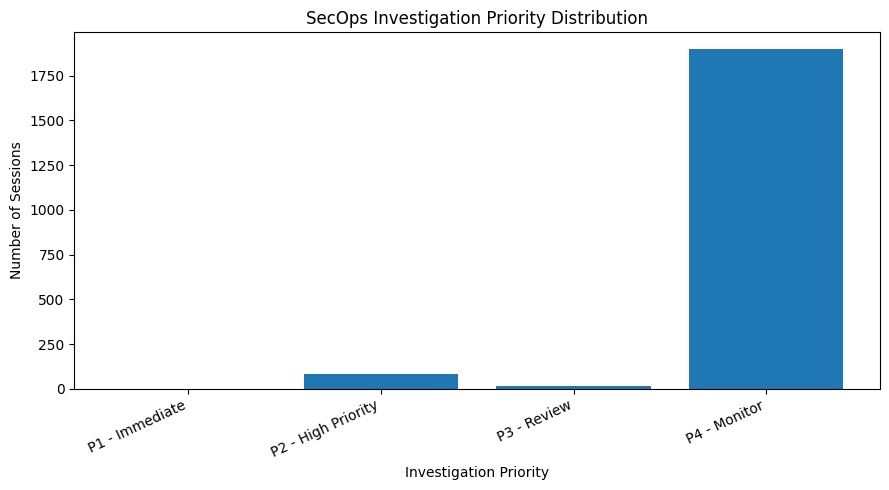

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/investigation_priority_distribution.png


In [147]:
# ============================================================
# Step 12: Investigation priority distribution
# ============================================================

priority_order = [
    "P1 - Immediate",
    "P2 - High Priority",
    "P3 - Review",
    "P4 - Monitor"
]

priority_counts = final_alert_triage_df["investigation_priority"].value_counts().reindex(
    priority_order
).fillna(0)

plt.figure(figsize=(9, 5))
plt.bar(priority_counts.index, priority_counts.values)
plt.title("SecOps Investigation Priority Distribution")
plt.xlabel("Investigation Priority")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

priority_fig_path = FIGURE_DIR / "investigation_priority_distribution.png"
plt.savefig(priority_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", priority_fig_path)

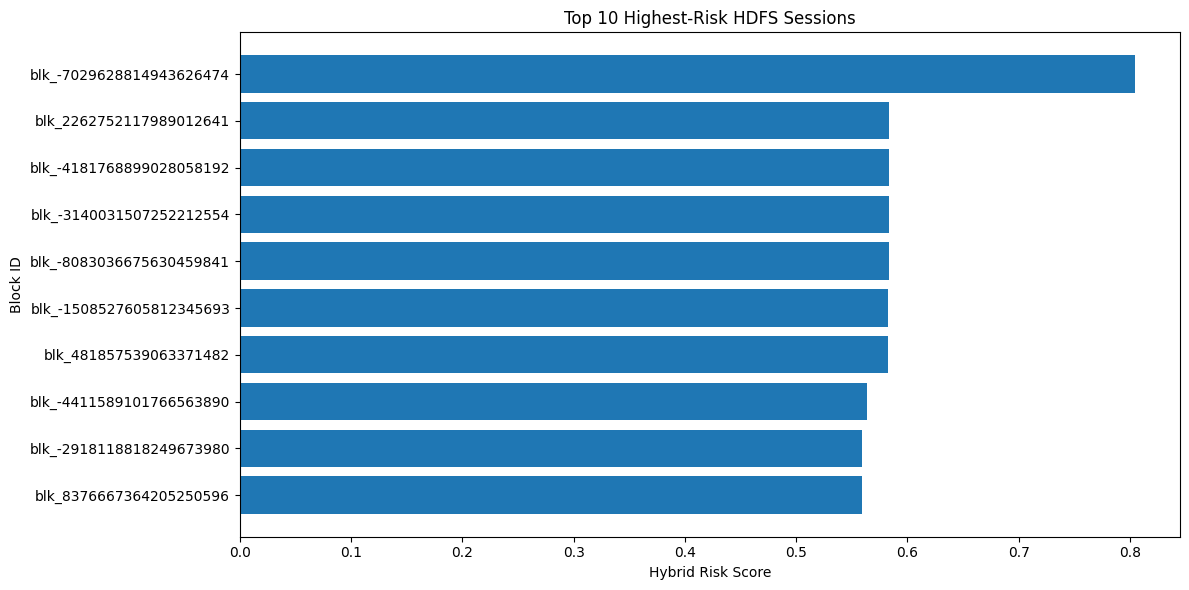

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/top_10_highest_risk_sessions.png


In [148]:
# ============================================================
# Step 12: Top 10 highest-risk sessions
# ============================================================

top_10_risk = final_alert_triage_df.head(10).copy()

plt.figure(figsize=(12, 6))
plt.barh(top_10_risk["block_id"], top_10_risk["hybrid_risk_score"])
plt.title("Top 10 Highest-Risk HDFS Sessions")
plt.xlabel("Hybrid Risk Score")
plt.ylabel("Block ID")
plt.gca().invert_yaxis()
plt.tight_layout()

top_10_risk_fig_path = FIGURE_DIR / "top_10_highest_risk_sessions.png"
plt.savefig(top_10_risk_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", top_10_risk_fig_path)

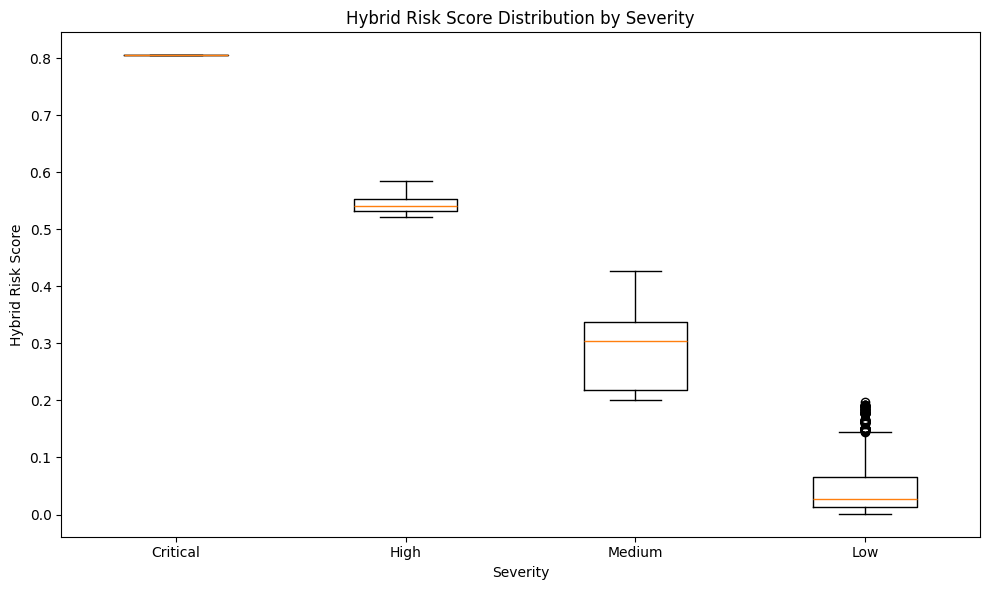

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/hybrid_risk_score_by_severity.png


In [149]:
# ============================================================
# Step 12: Hybrid risk score by severity
# ============================================================

severity_order = ["Critical", "High", "Medium", "Low"]

plt.figure(figsize=(10, 6))

data_to_plot = [
    final_alert_triage_df[
        final_alert_triage_df["final_severity"] == severity
    ]["hybrid_risk_score"].values
    for severity in severity_order
]

plt.boxplot(data_to_plot, labels=severity_order)
plt.title("Hybrid Risk Score Distribution by Severity")
plt.xlabel("Severity")
plt.ylabel("Hybrid Risk Score")
plt.tight_layout()

severity_score_fig_path = FIGURE_DIR / "hybrid_risk_score_by_severity.png"
plt.savefig(severity_score_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", severity_score_fig_path)

,Detection Layer,Session Count
0,Rule-Based Critical/High,80
1,Isolation Forest Anomalies,100
2,Rare Event Sessions,9
3,Rare Transition Sessions,6
4,P1/P2 Priority Alerts,81


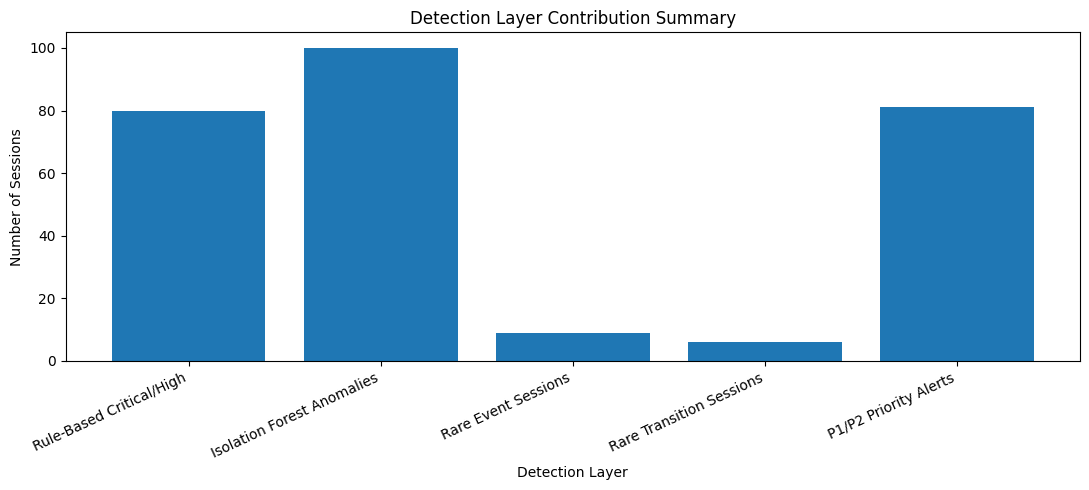

Saved figure: secops_log_anomaly_triage_hdfs/results/figures/detection_layer_contribution_summary.png


In [152]:
# ============================================================
# Step 12: Detection layer contribution summary
# ============================================================

layer_summary = {
    "Rule-Based Critical/High": int(
        final_alert_triage_df["rule_risk_level"].isin(["Critical", "High"]).sum()
    ),
    "Isolation Forest Anomalies": int(
        (final_alert_triage_df["isolation_label"] == "anomaly").sum()
    ),
    "Rare Event Sessions": int(
        (final_alert_triage_df["rare_event_count"] > 0).sum()
    ),
    "Rare Transition Sessions": int(
        (final_alert_triage_df["rare_transition_count"] > 0).sum()
    ),
    "P1/P2 Priority Alerts": int(
        final_alert_triage_df["investigation_priority"].isin(
            ["P1 - Immediate", "P2 - High Priority"]
        ).sum()
    )
}

layer_summary_df = pd.DataFrame({
    "Detection Layer": list(layer_summary.keys()),
    "Session Count": list(layer_summary.values())
})

display(layer_summary_df)

plt.figure(figsize=(11, 5))
plt.bar(layer_summary_df["Detection Layer"], layer_summary_df["Session Count"])
plt.title("Detection Layer Contribution Summary")
plt.xlabel("Detection Layer")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

layer_summary_fig_path = FIGURE_DIR / "detection_layer_contribution_summary.png"
plt.savefig(layer_summary_fig_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved figure:", layer_summary_fig_path)

layer_summary_df.to_csv(
    RESULTS_DIR / "detection_layer_contribution_summary.csv",
    index=False
)

In [153]:
# ============================================================
# Step 12: Create project metrics summary table
# ============================================================

project_metrics_summary = pd.DataFrame([
    {"Metric": "Total Sessions Analyzed", "Value": len(final_alert_triage_df)},
    {"Metric": "P1 Immediate Alerts", "Value": (final_alert_triage_df["investigation_priority"] == "P1 - Immediate").sum()},
    {"Metric": "P2 High Priority Alerts", "Value": (final_alert_triage_df["investigation_priority"] == "P2 - High Priority").sum()},
    {"Metric": "P3 Review Alerts", "Value": (final_alert_triage_df["investigation_priority"] == "P3 - Review").sum()},
    {"Metric": "P4 Monitor Alerts", "Value": (final_alert_triage_df["investigation_priority"] == "P4 - Monitor").sum()},
    {"Metric": "Isolation Forest Anomalies", "Value": (final_alert_triage_df["isolation_label"] == "anomaly").sum()},
    {"Metric": "Rare Event Sessions", "Value": (final_alert_triage_df["rare_event_count"] > 0).sum()},
    {"Metric": "Rare Transition Sessions", "Value": (final_alert_triage_df["rare_transition_count"] > 0).sum()},
    {"Metric": "Highest Hybrid Risk Score", "Value": round(final_alert_triage_df["hybrid_risk_score"].max(), 4)},
    {"Metric": "Top Alert Event Sequence", "Value": final_alert_triage_df.iloc[0]["event_sequence"]}
])

display(project_metrics_summary)

project_metrics_summary.to_csv(
    RESULTS_DIR / "project_metrics_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "project_metrics_summary.csv")

,Metric,Value
0,Total Sessions Analyzed,1994
1,P1 Immediate Alerts,1
2,P2 High Priority Alerts,80
3,P3 Review Alerts,16
4,P4 Monitor Alerts,1897
5,Isolation Forest Anomalies,100
6,Rare Event Sessions,9
7,Rare Transition Sessions,6
8,Highest Hybrid Risk Score,0.8049
9,Top Alert Event Sequence,E11 -> E3


Saved: secops_log_anomaly_triage_hdfs/results/project_metrics_summary.csv
